<a href="https://colab.research.google.com/github/fmssilva/DL_Proj/blob/main/assignment_1/task3/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

cell_id: 531b6311f5ef1441
cell_type: text_cell
content: # Pokemon Type Classification — DL Assignment 1
## Task 3 — Transfer Learning and Fine-Tuning

**Goal:** classify 3 600 Pokémon images into 9 types using pretrained CNN/ViT backbones, fine-tuning strategies, and augmentation/regularisation techniques. Results are compared against the best MLP (Task 1) and CNN (Task 2) models.

**Metric:** Macro-averaged F1 — used because class imbalance is 2.76× (Water 674 vs Ground 244). Accuracy would be misleading on an imbalanced dataset.

---
> ⚠️ **DO NOT click "Run All"** — this notebook takes ~40 min on a T4 GPU. Run experiment cells individually, or set `FAST_RUN=False` and run on Colab.

---
## Table of Contents

- [**Part 0 — Project Setup**](#part-0--project-setup)
  - [0.1 Config](#01--config)
  - [0.2 Import & Set Up](#02--import--set-up)
  - [0.3 Hot Reload (Colab Only)](#03--hot-reload-colab-only)
  - [0.4 Load Data](#04--load-data)
- [**Part 1 — Feature Extraction (Frozen Backbones)**](#part-1--feature-extraction-frozen-backbones)
  - [1.1 Results Tracker](#11--results-tracker)
  - [1.2 Shared Experiment Infrastructure](#12--shared-experiment-infrastructure)
  - [1.3 Baselines: MLP_ref & CNN_ref](#13--baselines-mlp_ref--cnn_ref)
  - [1.4 Backbone Architecture Summary & Registry](#14--backbone-architecture-summary--model-registry)
  - [1.5 Experiment A: EfficientNet-B0](#15--experiment-a-efficientnet-b0-feature-extraction)
  - [1.6 Experiment B: VGG-16](#16--experiment-b-vgg-16-feature-extraction)
  - [1.7 Experiment C: Swin-V2-t](#17--experiment-c-swin-transformer-v2-t-feature-extraction)
  - [1.8 Experiment D: ResNet-34](#18--experiment-d-resnet-34-feature-extraction)
  - [1.9 Experiment E: ConvNeXt-Tiny](#19--experiment-e-convnext-tiny-feature-extraction)
  - [1.10 Experiment F: Mobilenet-v3-large](#1.10--experiment-f-mobilenet-v3-large-feature-extraction)
  - [1.11 Experiment G: Mobilenet-v3-small](#1.11--experiment-g-mobilenet-v3-small-feature-extraction)
  - [1.12 Experiment H: Efficientnet-v2-s](#1.12--experiment-h-efficientnet-v2-s-feature-extraction)
  - [1.13 Experiment I: Efficientnet-v2-m](#1.13--experiment-i-efficientnet-v2-m-feature-extraction)
  - [1.14 Experiment J: Googlenet](#1.14--experiment-j-googlenet-feature-extraction)
  - [1.15 Experiment K: Resnext50-32x4d](#1.15--experiment-k-resnext50-32x4d-feature-extraction)
  - [1.16 Experiment L: Resnext101-64x4d](#1.16--experiment-l-resnext101-64x4d-feature-extraction)
  - [1.17 Experiment M: Alexnet](#1.17--experiment-m-alexnet-feature-extraction)
  - [1.18 Experiment N: Inception-v3](#1.18--experiment-n-inception-v3-feature-extraction)
  - [1.19 Part 1 Leaderboard & Backbone Selection](#1.19--part-1-leaderboard--backbone-selection)
- [**Part 2 — Fine-Tuning**](#part-2--fine-tuning)
  - [2.1 Part 2 Setup](#21--part-2-setup)
  - [2.2 Experiment F: Partial Fine-Tune](#22--experiment-f-partial-fine-tune-last-backbone-block)
  - [2.3 Experiment G: Full Fine-Tune](#23--experiment-g-full-fine-tune-all-backbone-layers)
  - [2.4 Part 2 Leaderboard & Fine-Tuning Analysis](#24--part-2-leaderboard--fine-tuning-analysis)
- [**Part 3 — Augmentation & Regularisation**](#part-3--augmentation--regularisation)
  - [3.1 Overview & Design Rationale](#31--overview--design-rationale)
  - [3.2 Data Augmentation Visualisation](#32--data-augmentation-pipelines-visualisation)
  - [3.3 Experiment H: Transfer Augmentation](#33--experiment-h-transfer-augmentation-frozen-backbone)
  - [3.4 Experiment I: Label Smoothing](#34--experiment-i-label-smoothing-ls01-frozen-backbone)
  - [3.5 Experiment J: WeightedRandomSampler](#35--experiment-j-weightedrandomsampler-frozen-backbone)
  - [3.6 Experiment K: AdamW](#36--experiment-k-adamw-frozen-backbone-weight_decay001)
  - [3.7 Experiment L: Best FT + Best Aug (Stacked)](#37--experiment-l-best-ft--best-aug-stacked)
  - [3.8 Part 3 Leaderboard](#38--part-3-leaderboard--all-experiments)
- [**Part 4 — Ensemble, Evaluation & Submission**](#part-4--ensemble-evaluation--submission)
  - [4.1 Per-Class F1 Heatmap](#41--per-class-f1-heatmap)
  - [4.2 Cross-Task Comparison](#42--cross-task-comparison)
  - [4.3 Ensemble Evaluation](#43--ensemble-evaluation)
  - [4.4 Best Model Deep Dive](#44--best-model-deep-dive)
  - [4.5 Final Submission](#45--final-submission)
  - [4.6 Save Outputs](#46--save-outputs)

---

**Code organisation:**
> All reusable logic lives in `src/`:
> - `src/models/transfer.py` — 5 transfer model classes with frozen/unfreezing utilities
> - `src/models/mlp.py`, `cnn.py` — MLP and CNN classes (Task 1/2 baselines)
> - `src/datasets/dataset.py` — RGB, augmented, and 224 px transform pipelines; loaders with sampler support
> - `src/training/train.py`, `early_stopping.py` — training loop, EarlyStopping on any metric
> - `src/evaluation/` — metrics, plots (training curves, confusion matrix), submission CSV, ensemble, persistence

**AI Assistance Disclosure:**
> Artificial intelligence tools (Claude, ChatGPT, GitHub Copilot) were used strategically to enhance development efficiency while maintaining full academic integrity. AI assistance was limited to debugging, unit-test writing, and result visualisation. All core concepts, architectural decisions, and algorithmic implementations were conceived and developed by the authors.

---

# **Part 0 — Project Setup**


## 0.1 -- Config

All run-level flags live here. **Flip `FAST_RUN` to `False` before running on Colab** to switch from the 2-epoch / 6-samples-per-class smoke test to the full 20-epoch / 3600-image training run.

In [1]:

# All run-level constants live HERE.
# Change FAST_RUN to switch between a quick smoke-test and a real Colab run.
# Nothing else needs touching.


# ==============  FLIP THESE FLAGS  ===============================
FAST_RUN         = False    # True = smoke-test (tiny data, 2 epochs) | False = real Colab run
SAVE_IN_EACH_RUN = False   # True = zip outputs to DRIVE_OUTPUTS_DIR after every experiment
USE_DRIVE        = False   # True = enable save/restore of outputs zip (Drive on Colab, local folder elsewhere)
# =================================================================

# === Task identifier — change this ONE constant when copying the notebook for Task 2 / Task 3.
TASK_NAME = "task3"

# ==== Drive / backup settings =====================================
# Shared Drive folder that holds the dataset zip and output backups.
# Anyone-with-the-link public share URL — no hardcoded personal MyDrive paths.
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1u2Xw2-4_L5OhPFjY_OsgNbMayrTI-ROR?usp=sharing"

# Name of the dataset zip inside DRIVE_FOLDER_URL.
DATA_FILE_NAME = "the-pokemon-are-in-there-2026-task-3.zip"

# Name of the outputs zip inside DRIVE_FOLDER_URL.
OUTPUTS_FILE_NAME = TASK_NAME + "_outputs.zip"

# Where to save/restore the outputs zip:
#   Colab -> inside your personal MyDrive (auto-mounted)
#   Local -> any local folder (created automatically if needed)
import sys as _sys
DRIVE_OUTPUTS_DIR = (
    "/content/drive/MyDrive/DL_Proj"
    if "google.colab" in _sys.modules
    else str(__import__("pathlib").Path.home() / "DL_Proj")
)


# ======== Training hyperparams =============================================
# IMG_SIZE=224: backbones are calibrated for ImageNet 224x224.
#   At 64px the spatial feature map collapses to ~2x2 -> near-random features.
# BATCH_SIZE=32: 224px images use 4x more GPU memory than 64px -> halve batch vs Task 2.
# EPOCHS=20: frozen heads converge in <=15 epochs; 20 gives early stopping room.
# PATIENCE=5: val_macro_f1 is noisy on small val sets -> need patience >= 5 to avoid early trigger.
EPOCHS      = 2  if FAST_RUN else 20
PATIENCE    = 1  if FAST_RUN else 7
LR          = 1e-3
BATCH_SIZE  = 8  if FAST_RUN else 32
IMG_SIZE    = 224
NUM_WORKERS = 8

# smoke-test data size: 9 classes x N = total training images
N_SAMPLES_PER_CLASS = 6   # 54 total -- enough to run the full pipeline in seconds

print(f"TASK_NAME         : {TASK_NAME}")
print(f"FAST_RUN          : {FAST_RUN}  (N_SAMPLES_PER_CLASS={N_SAMPLES_PER_CLASS if FAST_RUN else 'all'})")
print(f"EPOCHS            : {EPOCHS}  |  PATIENCE : {PATIENCE}  |  LR : {LR}")
print(f"BATCH_SIZE        : {BATCH_SIZE}  |  IMG_SIZE : {IMG_SIZE}x{IMG_SIZE}")
print(f"USE_DRIVE         : {USE_DRIVE}  |  SAVE_IN_EACH_RUN : {SAVE_IN_EACH_RUN}")
print(f"DRIVE_FOLDER_URL  : {DRIVE_FOLDER_URL}")
print(f"DRIVE_OUTPUTS_DIR : {DRIVE_OUTPUTS_DIR}")


TASK_NAME         : task3
FAST_RUN          : False  (N_SAMPLES_PER_CLASS=all)
EPOCHS            : 20  |  PATIENCE : 7  |  LR : 0.001
BATCH_SIZE        : 32  |  IMG_SIZE : 224x224
USE_DRIVE         : False  |  SAVE_IN_EACH_RUN : False
DRIVE_FOLDER_URL  : https://drive.google.com/drive/folders/1u2Xw2-4_L5OhPFjY_OsgNbMayrTI-ROR?usp=sharing
DRIVE_OUTPUTS_DIR : /content/drive/MyDrive/DL_Proj


## 0.2 -- Import & Set Up

Handles environment detection (Colab vs local), clones the repo and installs requirements when on Colab, sets the working directory to `assignment_1/`, and imports shared constants from `src/config.py`.

> **`autoreload` magic** is enabled locally so any edits to `src/` files are picked up automatically without restarting the kernel. On Colab, push the changes to GitHub first, then run the Hot Reload cell below.

In [2]:

# ── PROJECT IMPORT AND SET UP ─────────────────────────────────────────────────────────

import sys, os, time, json
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if not IN_COLAB:
  %load_ext autoreload
  %autoreload 2

if IN_COLAB:
    if not os.path.exists("/content/DL_Proj"):
        !git clone https://github.com/fmssilva/DL_Proj.git /content/DL_Proj
    else:
        !git -C /content/DL_Proj pull --ff-only
    os.chdir("/content/DL_Proj/assignment_1")
    %pip install -r requirements.txt -q
else:
    # notebook kernel starts in task1/ — step up to assignment_1/ root
    cwd = Path(os.getcwd())
    if cwd.name.startswith("task"):
        os.chdir(cwd.parent)

ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    SEED, CLASSES, NUM_CLASSES, DATA_DIR, OUT_DIR,
    get_task_out_dir, set_seed,
)

set_seed(SEED)

TASK_OUT_DIR = get_task_out_dir(TASK_NAME)
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH     = DATA_DIR / "train_labels.csv"
TRAIN_DIR    = DATA_DIR / "train"
TEST_DIR     = DATA_DIR / "test"

# On Windows, multiprocessing DataLoader workers deadlock in a notebook process.
# Force NUM_WORKERS=0 (main-process loading) on Windows to avoid hangs.
# On Colab/Linux the config value is respected (up to cpu_count()).
import multiprocessing
if os.name == "nt":   # Windows
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(NUM_WORKERS, multiprocessing.cpu_count())

print("-"*50)
print(f"ROOT        : {ROOT}")
print(f"TASK_NAME   : {TASK_NAME}  |  TASK_OUT_DIR : {TASK_OUT_DIR}")
print(f"EPOCHS      : {EPOCHS}  |  PATIENCE : {PATIENCE}  |  LR : {LR}")
print(f"BATCH_SIZE  : {BATCH_SIZE}  |  IMG_SIZE : {IMG_SIZE}x{IMG_SIZE}")
print(f"NUM_WORKERS : {NUM_WORKERS}  {'(forced 0 on Windows)' if os.name == 'nt' else ''}")
print(f"Device      : {device}  |  PyTorch {torch.__version__}")
print(f"Outputs     : {TASK_OUT_DIR.resolve()}")


Cloning into '/content/DL_Proj'...
remote: Enumerating objects: 1173, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 1173 (delta 16), reused 13 (delta 7), pack-reused 1140 (from 1)
Receiving objects: 100% (1173/1173), 85.78 MiB | 12.24 MiB/s, done.
Resolving deltas: 100% (801/801), done.
--------------------------------------------------
ROOT        : /content/DL_Proj/assignment_1
TASK_NAME   : task3  |  TASK_OUT_DIR : task3/outputs
EPOCHS      : 20  |  PATIENCE : 7  |  LR : 0.001
BATCH_SIZE  : 32  |  IMG_SIZE : 224x224
NUM_WORKERS : 2  
Device      : cuda  |  PyTorch 2.10.0+cu128
Outputs     : /content/DL_Proj/assignment_1/task3/outputs


## 0.3 -- Hot Reload (Colab only)

On Colab: push `src/` changes to GitHub → run this cell → all modules are pulled and reloaded in-place. No kernel restart needed, so all variables (model weights, `results_tracker`) are preserved.

On local: not needed — `autoreload 2` handles it automatically.

In [33]:
import importlib
import sys
from pathlib import Path

if IN_COLAB:
    # pull latest code from GitHub before reloading
    import os
    os.chdir(Path(ROOT).parent)
    os.system("git pull --ff-only")
    os.chdir(ROOT)

# reload every src.* module that is already loaded in this kernel
_reloaded, _skipped = [], []
for mod_name, mod in list(sys.modules.items()):
    if mod_name.startswith("src.") and hasattr(mod, "__file__") and mod.__file__:
        try:
            importlib.reload(mod)
            _reloaded.append(mod_name)
        except Exception as e:
            print(f"  [WARN] could not reload {mod_name}: {e}")
            _skipped.append(mod_name)

print(f"Reloaded {len(_reloaded)} src modules: {_reloaded}")
if _skipped:
    print(f"Skipped  {len(_skipped)}: {_skipped}")


Reloaded 15 src modules: ['src.config', 'src.evaluation', 'src.evaluation.persistence', 'src.datasets', 'src.datasets.dataset', 'src.models', 'src.models.mlp', 'src.models.transfer', 'src.models.cnn', 'src.training', 'src.evaluation.metrics', 'src.training.train', 'src.training.early_stopping', 'src.evaluation.plots', 'src.evaluation.submission']


## 0.4 -- Load Data

Downloads and extracts the dataset from Google Drive if not already present (uses `DRIVE_FOLDER_URL`). Then reads `train_labels.csv` and — in `FAST_RUN` mode — subsamples to `N_SAMPLES_PER_CLASS` images per class so every downstream cell finishes in seconds on CPU.

In [4]:
from src.evaluation.persistence import download_and_extract

# Download and extract the dataset if not already present.
# Uses DRIVE_FOLDER_URL + DATA_FILE_NAME from Config — works on Colab and locally.
if not Path("data/train_labels.csv").exists():
    ok = download_and_extract(DRIVE_FOLDER_URL, DATA_FILE_NAME, "data/")
    if not ok:
        print(
            "ERROR: data download failed.\n"
            f"  Folder : {DRIVE_FOLDER_URL}\n"
            f"  File   : {DATA_FILE_NAME}\n"
            "  Check that the folder is publicly shared and the file name is correct."
        )
else:
    print("data/ already present — skipping download")


df_full = pd.read_csv(CSV_PATH)
print(f"Full dataset : {len(df_full)} rows, {df_full['label'].nunique()} classes")

# FAST_RUN: subsample N per class so every cell finishes fast on CPU
if FAST_RUN:
    df = df_full.groupby("label", group_keys=False).head(N_SAMPLES_PER_CLASS).reset_index(drop=True)
    print(f"FAST_RUN     : subsampled to {len(df)} rows ({N_SAMPLES_PER_CLASS}/class)")
else:
    df = df_full

print(f"\nClass counts used this run:\n{df['label'].value_counts().to_string()}")

Downloading...
From (original): https://drive.google.com/uc?id=1JGMsjUNwZ2NNw1yEv-CEiYp04JENjDwz
From (redirected): https://drive.google.com/uc?id=1JGMsjUNwZ2NNw1yEv-CEiYp04JENjDwz&confirm=t&uuid=f06d1ebe-8426-4d46-bb93-5dc4edd15185
To: /tmp/tmp5zlokn13/the-pokemon-are-in-there-2026-task-3.zip
100%|██████████| 296M/296M [00:09<00:00, 29.9MB/s]


[download_from_drive] 'the-pokemon-are-in-there-2026-task-3.zip' -> /tmp/tmp5zlokn13/the-pokemon-are-in-there-2026-task-3.zip
Full dataset : 1194 rows, 9 classes

Class counts used this run:
label
Water       252
Normal      222
Grass       159
Bug         150
Fire        114
Rock         99
Ground       72
Poison       66
Fighting     60


---

# **Part 1 — Feature Extraction (Frozen Backbones)**

Five pretrained CNN/ViT backbones are tested with **all backbone weights frozen** — only a small classification head is trained. This isolates the quality of the pretrained features from training dynamics.

**Goal:** find the best backbone before any fine-tuning. The winner carries forward into Part 2 (fine-tuning) and Part 3 (augmentation/regularisation).

## 1.1 -- Results Tracker

`results_tracker` is a global dictionary that accumulates every experiment result throughout the notebook. Each entry is keyed by experiment stem (e.g. `"D_ResNet34_Base"`) and stores `val_macro_f1`, `val_acc`, `total_epochs`, `train_time_s`, and the full per-epoch `history`.

Results are persisted to `task3_results.json` after every experiment, so a Colab disconnect loses at most the current run. You can also restore a previous run's results by uploading the outputs zip and running the restore cell below.

> **Optional — Restore Previous Outputs:** Run the two cells below only if you want to reload `results_tracker` from a previously saved outputs zip on Google Drive. Skip them to start fresh (default).


In [5]:
from src.evaluation.persistence import restore_outputs

# Restore previous outputs from Drive/local backup.
# On Colab  : mounts Drive and reads from DRIVE_OUTPUTS_DIR (private mounted path).
# Locally   : downloads from DRIVE_FOLDER_URL (public shared folder).
# Skip entirely when USE_DRIVE=False — nothing to restore.

if USE_DRIVE:
    backup_dir = DRIVE_OUTPUTS_DIR if IN_COLAB else DRIVE_FOLDER_URL
    restore_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, backup_dir=backup_dir)
else:
    print("[restore] USE_DRIVE=False — skipping restore, starting fresh.")

[restore] USE_DRIVE=False — skipping restore, starting fresh.


In [6]:
from src.evaluation.persistence import restore_tracker, ResultsTracker
import sys

# ResultsTracker = dict[str, ExperimentEntry]
# Each entry has these keys (see ExperimentEntry in persistence.py):
#   val_macro_f1 : float  — best val macro-F1 from the saved checkpoint
#   val_acc      : float  — val accuracy at that checkpoint
#   val_loss     : float  — val loss at that checkpoint (nan for ensembles)
#   total_epochs : int    — epochs actually run (< EPOCHS if early-stopped; 0 for ensembles)
#   train_time_s : float  — wall-clock training time in seconds (0.0 for ensembles)
#   history      : dict   — {"train_loss": [...], "val_loss": [...], "train_f1": [...], "val_f1": [...]}
#   child_models : list   — only present on ensemble entries; names of the averaged solo models
results_tracker: ResultsTracker = {}

results_json_path = TASK_OUT_DIR / "results" / f"{TASK_NAME}_results.json"

def _print_leaderboard(tracker: ResultsTracker) -> None:
    """Show all experiments sorted by val_macro_f1 as a styled HTML DataFrame.
    Flushes stdout first so Jupyter doesn't re-print buffered output when display() fires.
    Safe to call from both experiment cells and dedicated leaderboard cells."""
    if not tracker:
        return
    rows = sorted(tracker.items(), key=lambda x: x[1]["val_macro_f1"], reverse=True)
    data = [
        {
            "rank":    rank,
            "name":    name,
            "val_F1":  round(m["val_macro_f1"], 4),
            "val_acc": round(m["val_acc"], 4),
            "epochs":  m["total_epochs"],
            "time(s)": round(m["train_time_s"], 1),
        }
        for rank, (name, m) in enumerate(rows, 1)
    ]
    df_lb = pd.DataFrame(data).set_index("rank")
    # flush stdout BEFORE display() so Jupyter doesn't re-emit buffered print lines
    sys.stdout.flush()
    try:
        from IPython.display import display
        styled = (
            df_lb.style
            .background_gradient(subset=["val_F1"], cmap="RdYlGn", vmin=0.0, vmax=1.0)
            .background_gradient(subset=["val_acc"], cmap="Blues", vmin=0.0, vmax=1.0)
            .format({"val_F1": "{:.4f}", "val_acc": "{:.4f}", "time(s)": "{:.1f}"})
        )
        display(styled)
    except Exception:
        print(df_lb.to_string())


# _print_result: compact one-liner summary for a single experiment
# (kept for internal use; experiment cells call _print_leaderboard for the full styled table)
def _print_result(name: str) -> None:
    if name not in results_tracker:
        return
    e = results_tracker[name]
    ranked = sorted(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"], reverse=True)
    rank = ranked.index(name) + 1
    total = len(ranked)
    sys.stdout.flush()
    print(
        f"\n  → [{rank}/{total}]  {name}  "
        f"val_F1={e['val_macro_f1']:.4f}  val_acc={e['val_acc']:.4f}  "
        f"({e['total_epochs']} ep, {e['train_time_s']:.0f}s)"
    )


print("-" * 50)
restore_tracker(results_json_path, results_tracker)
print("Current experiments in results_tracker:")
_print_leaderboard(results_tracker)


--------------------------------------------------
No results JSON found at task3/outputs/results/task3_results.json — starting fresh.
Current experiments in results_tracker:


## 1.2 -- Shared Experiment Infrastructure

All experiment cells call two helpers defined here:

- **`build_loaders(use_sampler, transfer_aug)`** — wraps `get_train_val_loaders`; always uses the current `df` (subsampled in `FAST_RUN`). `transfer_aug=True` applies the gentle 224 px Pokemon-specific augmentation pipeline; `use_sampler=True` enables `WeightedRandomSampler` for class-balanced batches.
- **`build_loaders_64(use_sampler, augment)`** — same but at 64 px; used only by `MLP_ref` and `CNN_ref` which were trained without ImageNet-sized inputs.
- **`run_experiment(model, name, ...)`** — full training loop: AMP mixed-precision on CUDA, `EarlyStopping` on `val_macro_f1`, scheduler dispatch (handles both `StepLR` and `ReduceLROnPlateau` correctly), checkpoint save, immediate JSON persist, auto-submission update if a new best is reached.

Each experiment cell is then just 5–6 lines: instantiate model → criterion → optimizer → scheduler → `run_experiment()`.

In [34]:

# ── Shared imports for all experiment cells ───────────────────────────────────
import torch.nn as nn
from torch.utils.data import DataLoader
from src.datasets.dataset import (
    PokemonDataset, compute_class_weights,
    get_base_transforms, get_train_val_loaders,
    get_transfer_aug_transforms,               # gentle 224px augmentation pipeline
)
from src.models.transfer import (
    EfficientNetB0Transfer, VGG_16_Transfer, Swin_V2_t_Transfer,
    ResNet34_Transfer, ConvNext_tiny_Transfer,
    Efficientnet_v2_s_Transfer, ResNet18Transfer,
    unfreeze_backbone, get_backbone_lr_groups, # used in Part 2 fine-tuning cells
)
from src.models.mlp import MLP
from src.models.cnn import MultiScaleCNN
from src.training.train import train_one_epoch, evaluate
from src.training.early_stopping import EarlyStopping
from src.evaluation.metrics import classification_report_str
from src.evaluation.plots import plot_history, plot_confusion_matrix
from src.evaluation.persistence import save_experiment_result, save_all_results, save_outputs
from src.evaluation.submission import generate_submission_from_preds, validate_submission

import time

# build class weights from the run's df (correct proportions even for FAST_RUN)
label_to_idx      = {cls: i for i, cls in enumerate(CLASSES)}
_all_train_labels = [label_to_idx[lbl] for lbl in df["label"]]
class_weights     = compute_class_weights(_all_train_labels).to(device)

# test loader: standard RGB 224px, no augmentation, no shuffling
test_ds     = PokemonDataset(TEST_DIR, get_base_transforms(IMG_SIZE), csv_path=None)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 64px test loader -- used by MLP_ref and CNN_ref for submission checks
IMG_SIZE_64    = 64
test_ds_64     = PokemonDataset(TEST_DIR, get_base_transforms(IMG_SIZE_64), csv_path=None)
test_loader_64 = DataLoader(test_ds_64, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# single path for incremental per-experiment saves
RESULTS_PATH = TASK_OUT_DIR / "results" / f"{TASK_NAME}_results.json"
SUB_PATH     = TASK_OUT_DIR / "results" / f"submission_{TASK_NAME}.csv"

print(f"Test images (224px): {len(test_ds)}")
print(f"Test images ( 64px): {len(test_ds_64)}")
print(f"Class weights: { {cls: round(class_weights[i].item(), 3) for i, cls in enumerate(CLASSES)} }")


# ── Helper: build_loaders ─────────────────────────────────────────────────────
def build_loaders(use_sampler: bool = False, transfer_aug: bool = False):
    """Return (train_loader, val_loader) for 224px transfer experiments.
    transfer_aug=True -> uses get_transfer_aug_transforms (gentle 224px Pokemon pipeline).
    use_sampler=True  -> WeightedRandomSampler for balanced batch composition."""
    train_transform = get_transfer_aug_transforms(IMG_SIZE) if transfer_aug else None
    return get_train_val_loaders(
        CSV_PATH, TRAIN_DIR, IMG_SIZE, BATCH_SIZE,
        augment=False, use_sampler=use_sampler,
        num_workers=NUM_WORKERS, df_override=df,
        train_transform=train_transform,
    )


# ── Helper: build_loaders_64 ──────────────────────────────────────────────────
def build_loaders_64(use_sampler: bool = False, augment: bool = True):
    """Return (train_loader, val_loader) at 64px -- used by MLP_ref and CNN_ref.
    Standard ImageNet-free normalization; augment=True adds horizontal flip + small crop.
    use_sampler=True -> WeightedRandomSampler (class-balanced batches)."""
    return get_train_val_loaders(
        CSV_PATH, TRAIN_DIR, IMG_SIZE_64, BATCH_SIZE,
        augment=augment, use_sampler=use_sampler,
        num_workers=NUM_WORKERS, df_override=df,
    )


# pre-build loader pairs
loaders_base    = build_loaders(use_sampler=False, transfer_aug=False)
loaders_base_64 = build_loaders_64(use_sampler=False, augment=False)  # plain 64px, no aug
_, val_loader   = loaders_base   # 224px val -- used by per-class delta cell


# ── Helper: _make_test_loader ─────────────────────────────────────────────────
def _make_test_loader(stem: str) -> DataLoader:
    """Returns the right test loader based on stem.
    MLP_ref and CNN_ref use 64px; all transfer models use 224px."""
    if stem in ("MLP_ref", "CNN_ref"):
        return test_loader_64
    return test_loader


# ── Helper: _is_new_overall_best ─────────────────────────────────────────────
def _is_new_overall_best(name: str, f1: float) -> bool:
    """True if this experiment beats every other entry in results_tracker."""
    other_f1s = [v["val_macro_f1"] for k, v in results_tracker.items() if k != name]
    return f1 > max(other_f1s, default=-1)



# ── Helper: run_experiment ────────────────────────────────────────────────────
def run_experiment(model, name: str, criterion, optimizer, scheduler, loaders) -> tuple:
    """
    Train model up to EPOCHS with early stopping on val macro-F1.
    - AMP (mixed precision) enabled on CUDA: ~2x throughput at 224px, halves memory.
    - Scheduler dispatch: ReduceLROnPlateau.step(val_loss) vs StepLR.step() -- not the same call.
      Calling step() with no args on ReduceLROnPlateau is a silent bug (does nothing).
    - Saves best checkpoint, upserts results.json after each run.
    - Does NOT call _print_leaderboard internally -- call it from the experiment cell after
      run_experiment returns. This avoids duplicate stdout caused by display() mid-function.
    Returns (model_with_best_weights, history_dict).
    """
    train_loader, val_loader = loaders
    ckpt_path = str(TASK_OUT_DIR / "checkpoints" / f"{name}.pth")
    stopper   = EarlyStopping(patience=PATIENCE, checkpoint_path=ckpt_path)
    history   = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    t0        = time.time()

    # AMP scaler: speeds up 224px training significantly on T4; None on CPU (no-op path)
    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    print(f"\n{'='*60}")
    print(f"  Experiment: {name}")
    print(f"  Model params: {sum(p.numel() for p in model.parameters()):,}  "
          f"trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*60}")

    for epoch in range(1, EPOCHS + 1):
        ep_t0         = time.time()
        train_loss    = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler=scaler)
        train_metrics = evaluate(model, train_loader, criterion, device)
        val_metrics   = evaluate(model, val_loader,   criterion, device)
        val_loss      = val_metrics["loss"]
        elapsed       = time.time() - ep_t0

        # scheduler dispatch -- ReduceLROnPlateau needs the metric, StepLR needs nothing
        # calling .step() with no args on ReduceLROnPlateau silently does nothing (silent bug)
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_metrics["macro_f1"])
        history["val_f1"].append(val_metrics["macro_f1"])

        print(
            f"  Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f}  train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_loss={val_loss:.4f}  val_f1={val_metrics['macro_f1']:.4f} | "
            f"{elapsed:.1f}s"
        )

        # negate val_f1 because EarlyStopping minimises -- this saves the peak-F1 checkpoint
        stopper(-val_metrics["macro_f1"], model)
        if stopper.stop:
            print(f"  Early stopping at epoch {epoch} (patience={PATIENCE}, metric: val_macro_f1).")
            break

    total_time = time.time() - t0

    # reload best checkpoint and run a final clean evaluation
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    best = evaluate(model, val_loader, criterion, device)

    entry = {
        "val_macro_f1": round(best["macro_f1"], 4),
        "val_acc":      round(best["acc"], 4),
        "val_loss":     round(best["loss"], 4),
        "total_epochs": len(history["train_loss"]),
        "train_time_s": round(total_time, 1),
        "history":      history,
    }
    results_tracker[name] = entry

    print(f"\n  Best checkpoint: val_loss={best['loss']:.4f}  val_macro_f1={best['macro_f1']:.4f}")
    print(f"  Total time: {total_time:.1f}s ({total_time/len(history['train_loss']):.1f}s/epoch)")
    # NOTE: leaderboard NOT printed here -- call _print_leaderboard() from the experiment cell
    # after run_experiment returns. Avoids duplicate stdout caused by display() mid-stream.

    # save this experiment's result to disk immediately -- no data lost if Colab disconnects
    save_experiment_result(name, entry, RESULTS_PATH)

    # auto-update submission if this solo model beats everyone (solo + ensemble)
    if _is_new_overall_best(name, entry["val_macro_f1"]):
        print(f"\n  New overall best -- regenerating submission CSV...")
        _tl = _make_test_loader(name)
        test_preds = []
        model.eval()
        with torch.no_grad():
            for imgs, _ in _tl:
                imgs = imgs.to(device)
                test_preds.extend(model(imgs).argmax(dim=1).cpu().tolist())
        generate_submission_from_preds(_tl, test_preds, CLASSES, SUB_PATH)
        validate_submission(SUB_PATH)
        print(f"  Submission updated -> {SUB_PATH}")

    if SAVE_IN_EACH_RUN:
        save_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, use_drive=USE_DRIVE, drive_dir=DRIVE_OUTPUTS_DIR)

    return model, history


# ── Helper: _print_result ─────────────────────────────────────────────────────
def _print_result(name: str) -> None:
    """Print a compact one-line summary for a single experiment.
    Call this from experiment cells instead of the full _print_leaderboard
    to keep individual cell outputs concise.
    Format:  [rank/total]  name  val_F1=X.XXXX  val_acc=X.XXXX
    """
    if name not in results_tracker:
        return
    e = results_tracker[name]
    ranked = sorted(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"], reverse=True)
    rank   = ranked.index(name) + 1
    total  = len(ranked)
    print(
        f"\n  → [{rank}/{total}]  {name}  "
        f"val_F1={e['val_macro_f1']:.4f}  val_acc={e['val_acc']:.4f}  "
        f"({e['total_epochs']} ep, {e['train_time_s']:.0f}s)"
    )


Test images (224px): 300
Test images ( 64px): 300
Class weights: {'Bug': 0.884, 'Fighting': 2.211, 'Fire': 1.164, 'Grass': 0.834, 'Ground': 1.843, 'Normal': 0.598, 'Poison': 2.01, 'Rock': 1.34, 'Water': 0.526}


## 1.3 -- Baselines: MLP_ref & CNN_ref

Before evaluating pretrained backbones we establish two scratch-trained baselines:

| Model | Architecture | Input | Params | Purpose |
|-------|-------------|-------|--------|---------|
| **MLP_ref** | 3-layer MLP (Task 1 best) | 64 × 64 × 3 flat | 6.5 M | Lower-bound: no spatial inductive bias |
| **CNN_ref** | 5-block CNN (Task 2 best) | 64 × 64 RGB | 181 K | Stronger lower-bound: local feature extraction |

Both are retrained from scratch on the **Task 3 data split** to ensure a fair comparison (same train/val images as all transfer experiments).

> **[FAST_RUN]** F1 scores will be near-random (2 epochs, 54 samples). Rerun with FAST_RUN=False for real numbers.


In [9]:

# ── MLP_ref: best MLP recipe from Task 1 (R_ls015_drop03) ────────────────────
# MLP([512, 256, 128], drop=0.3) + CE(weights, LS=0.15) + Adam(lr=1e-3, WD=1e-4) + StepLR
# Trained at 64px, no augmentation, plain 80/20 split.

loaders_mlp = build_loaders_64(use_sampler=False, augment=False)

model_mlp     = MLP(layers=[512, 256, 128], img_size=IMG_SIZE_64, dropout=0.3, use_bn=True).to(device)
criterion_mlp = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.15)
optimizer_mlp = torch.optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_mlp = torch.optim.lr_scheduler.StepLR(optimizer_mlp, step_size=7, gamma=0.5)

model_mlp, history_mlp = run_experiment(model_mlp, "MLP_ref", criterion_mlp, optimizer_mlp, scheduler_mlp, loaders_mlp)
_print_leaderboard(results_tracker)



  Experiment: MLP_ref
  Model params: 6,459,145  trainable: 6,459,145
  Epoch 01/20 | train_loss=2.4047  train_f1=0.1718 | val_loss=2.3746  val_f1=0.0537 | 11.0s
  Epoch 02/20 | train_loss=2.2967  train_f1=0.2106 | val_loss=2.3427  val_f1=0.0515 | 10.6s
  Epoch 03/20 | train_loss=2.2367  train_f1=0.2296 | val_loss=2.3719  val_f1=0.0482 | 10.4s
  Epoch 04/20 | train_loss=2.1976  train_f1=0.3166 | val_loss=2.3573  val_f1=0.0717 | 10.3s
  Epoch 05/20 | train_loss=2.1532  train_f1=0.3281 | val_loss=2.3936  val_f1=0.0591 | 9.4s
  Epoch 06/20 | train_loss=2.0474  train_f1=0.4002 | val_loss=2.4581  val_f1=0.0739 | 10.4s
  Epoch 07/20 | train_loss=1.9664  train_f1=0.4842 | val_loss=2.4575  val_f1=0.0931 | 10.4s
  Epoch 08/20 | train_loss=1.8397  train_f1=0.5766 | val_loss=2.4721  val_f1=0.0987 | 11.3s
  Epoch 09/20 | train_loss=1.7463  train_f1=0.6681 | val_loss=2.4782  val_f1=0.0904 | 10.4s
  Epoch 10/20 | train_loss=1.6533  train_f1=0.7112 | val_loss=2.4946  val_f1=0.1247 | 9.2s
  Epoch 11/

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,MLP_ref,0.1634,0.1757,20,206.4


In [10]:

# ── CNN_ref: best CNN recipe from Task 2 (reg_F_multiscale_sampler) ───────────
# MultiScaleCNN(drop=0.3) + CE(weights, LS=0.1) + Adam(lr=1e-3, WD=1e-4) + StepLR
# Trained at 64px with WeightedRandomSampler, no extra augmentation.

loaders_cnn = build_loaders_64(use_sampler=True, augment=False)

model_cnn     = MultiScaleCNN(in_channels=3, dropout=0.3).to(device)
criterion_cnn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_cnn = torch.optim.lr_scheduler.StepLR(optimizer_cnn, step_size=7, gamma=0.5)

model_cnn, history_cnn = run_experiment(model_cnn, "CNN_ref", criterion_cnn, optimizer_cnn, scheduler_cnn, loaders_cnn)
_print_leaderboard(results_tracker)



  Experiment: CNN_ref
  Model params: 181,001  trainable: 181,001
  Epoch 01/20 | train_loss=2.4261  train_f1=0.0955 | val_loss=2.4988  val_f1=0.0184 | 10.7s
  Epoch 02/20 | train_loss=2.0284  train_f1=0.2360 | val_loss=2.4119  val_f1=0.0438 | 10.6s
  Epoch 03/20 | train_loss=1.8874  train_f1=0.2893 | val_loss=2.4471  val_f1=0.0521 | 10.7s
  Epoch 04/20 | train_loss=1.7773  train_f1=0.3248 | val_loss=2.5274  val_f1=0.0459 | 10.5s
  Epoch 05/20 | train_loss=1.6616  train_f1=0.3797 | val_loss=2.4717  val_f1=0.0636 | 9.5s
  Epoch 06/20 | train_loss=1.6279  train_f1=0.4587 | val_loss=2.4260  val_f1=0.0682 | 10.6s
  Epoch 07/20 | train_loss=1.4691  train_f1=0.5159 | val_loss=2.4326  val_f1=0.0598 | 10.5s
  Epoch 08/20 | train_loss=1.3313  train_f1=0.5479 | val_loss=2.4353  val_f1=0.0744 | 10.5s
  Epoch 09/20 | train_loss=1.2487  train_f1=0.6861 | val_loss=2.5090  val_f1=0.0685 | 10.7s
  Epoch 10/20 | train_loss=1.1001  train_f1=0.6423 | val_loss=2.4563  val_f1=0.0887 | 9.4s
  Epoch 11/20 |

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,MLP_ref,0.1634,0.1757,20,206.4
2,CNN_ref,0.1171,0.1464,20,206.2


## 1.4 -- Backbone Architecture Summary & Model Registry

Five ImageNet-pretrained backbones are evaluated as frozen feature extractors. Only the classification head (a single linear layer) is trained.

| Model | Total params | Trainable | % | ImageNet top-1 |
|-------|-------------|-----------|---|----------------|
| EfficientNet-B0 | 4.0 M | ~12 K | 0.3% | 77.7% |
| VGG-16 | 134 M | ~120 M | 89% | 71.6% |
| Swin-V2-t | 28 M | ~7 K | 0.02% | 82.1% |
| ResNet-34 | 21 M | ~5 K | 0.02% | 73.3% |
| ConvNeXt-Tiny | 28 M | ~8 K | 0.03% | 82.1% |

> Note: VGG-16 has a large classifier MLP (two 4096-unit layers) which is fully trainable → 89% parameters are in the head, making it more like partial fine-tuning than strict feature extraction.


In [11]:

# Compact param count summary -- shows how many params each backbone has
# and how many are trainable in Stage 1 (head only).
# MLP_ref and CNN_ref are fully trainable (no frozen backbone).
print(f"{'Model':<22} {'Total Params':>14} {'Trainable':>12}  {'% trainable':>12}")
print("-" * 66)

# Transfer models -- mostly frozen in Stage 1
for label, cls in [
    ("EfficientNet-B0", EfficientNetB0Transfer),
    ("VGG-16",          VGG_16_Transfer),
    ("Swin-V2-t",       Swin_V2_t_Transfer),
    ("ResNet-34",       ResNet34_Transfer),
    ("ConvNeXt-Tiny",   ConvNext_tiny_Transfer),
    ("Efficientnet_v2_s",   Efficientnet_v2_s_Transfer),
    ("ResNet-18",          ResNet18Transfer)
]:
    m         = cls(dropout=0.4)
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {label:<20} {total:>14,} {trainable:>12,}  {100*trainable/total:>11.2f}%")

print()

# Baseline models -- fully trainable
mlp_ref = MLP(layers=[512, 256, 128], img_size=IMG_SIZE_64, dropout=0.3, use_bn=True)
cnn_ref = MultiScaleCNN(in_channels=3, dropout=0.3)
for label, m in [("MLP_ref (64px)", mlp_ref), ("CNN_ref (64px)", cnn_ref)]:
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {label:<20} {total:>14,} {trainable:>12,}  {100*trainable/total:>11.2f}%  [baseline]")


Model                    Total Params    Trainable   % trainable
------------------------------------------------------------------
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 192MB/s]


  EfficientNet-B0           4,019,077       11,529         0.29%
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 97.2MB/s]


  VGG-16                  134,297,417  119,582,729        89.04%
Downloading: "https://download.pytorch.org/models/swin_v2_t-b137f0e2.pth" to /root/.cache/torch/hub/checkpoints/swin_v2_t-b137f0e2.pth


...

  ConvNeXt-Tiny            27,827,049        8,457         0.03%
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 175MB/s]


  Efficientnet_v2_s        20,189,017       11,529         0.06%
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 16.9MB/s]

  ResNet-18                11,756,593       67,081         0.57%

  MLP_ref (64px)            6,459,145    6,459,145       100.00%  [baseline]
  CNN_ref (64px)              181,001      181,001       100.00%  [baseline]


In [16]:

# Registry: one entry per experiment stem.
# "model"     -- zero-arg factory (RGB, in_channels=3).
# "criterion" -- zero-arg factory; must match what was used during training.
# Standardised across all A-E: dropout=0.4, CrossEntropyLoss(weight=class_weights).
# That way any F1 difference in Part 1 = backbone quality, not hyperparameter mismatch.
# MLP_ref and CNN_ref use 64px loaders (see loader_fn_registry in Part 4 heatmap cell).
model_registry = {
    "MLP_ref": {
        "model":     lambda: MLP(layers=[512, 256, 128], img_size=IMG_SIZE_64, dropout=0.3, use_bn=True),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.15),
    },
    "CNN_ref": {
        "model":     lambda: MultiScaleCNN(in_channels=3, dropout=0.3),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1),
    },
    "A_EfficNetB0_Base": {
        "model":     lambda: EfficientNetB0Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "B_VGG16_Base": {
        "model":     lambda: VGG_16_Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "C_SwinV2t_Base": {
        "model":     lambda: Swin_V2_t_Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "D_ResNet34_Base": {
        "model":     lambda: ResNet34_Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "E_ConvNext_Base": {
        "model":     lambda: ConvNext_tiny_Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },

    "F_EfficNetB0_Cust": {
        "model":     lambda: EfficientNetB0Transfer(dropout=0.7, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },

    "G_VGG16_Cust": {
        "model":     lambda: VGG_16_Transfer(dropout=0.7, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },

    "I_ResNet34_Cust": {
        "model":     lambda: ResNet34_Transfer(dropout=0.7, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "J_ConvNext_Cust": {
        "model":     lambda: ConvNext_tiny_Transfer(dropout=0.7, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },

    "K_SwinV2t_Cust":{
        "model":     lambda: Swin_V2_t_Transfer(dropout=0.7, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "L_Efficientnet_v2_s_Cust":{
        "model":     lambda: Efficientnet_v2_s_Transfer(dropout=0.7, head="SIMPLE"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },

    "M_ResNet18_Cust":{
        "model": lambda: ResNet18Transfer(dropout=0.7),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },


    "H_Efficientnet_v2_s": {
        "model":     lambda: Efficientnet_v2_s_Transfer(dropout=0.4),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "N_SwinV2t_MLP":{
        "model":     lambda: Swin_V2_t_Transfer(dropout=0.7, head="MLP"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    },
    "O_Efficientnet_v2_s_MLP":{
        "model":     lambda: Efficientnet_v2_s_Transfer(dropout=0.7, head="MLP"),
        "criterion": lambda: nn.CrossEntropyLoss(weight=class_weights),
    }
}

print("model_registry loaded:", list(model_registry.keys()))


model_registry loaded: ['MLP_ref', 'CNN_ref', 'A_EfficNetB0_Base', 'B_VGG16_Base', 'C_SwinV2t_Base', 'D_ResNet34_Base', 'E_ConvNext_Base', 'F_EfficNetB0_Cust', 'G_VGG16_Cust', 'I_ResNet34_Cust', 'J_ConvNext_Cust', 'K_SwinV2t_Cust', 'L_Efficientnet_v2_s_Cust', 'M_ResNet18_Cust', 'H_Efficientnet_v2_s', 'N_SwinV2t_MLP', 'O_Efficientnet_v2_s_MLP']


## 1.5 -- Experiment A: EfficientNet-B0 (Feature Extraction)

- **Backbone:** `efficientnet_b0` (torchvision, ImageNet pretrained), fully frozen.
- **Head:** single `nn.Linear(1280 → 9)`.
- **Input:** 224 × 224 RGB, ImageNet normalisation. No augmentation.
- **Rationale:** strong accuracy/efficiency Pareto point. MBConv blocks with squeeze-and-excitation. Expected to generalise well to Pokémon sprites despite domain gap.

> **[FAST_RUN]** Update F1 after Colab run.


In [18]:

# A -- EfficientNet-B0: feature extraction baseline
# Backbone FROZEN (no gradient). Only Dropout(0.4)->Linear(1280,9) head trains.
# Settings identical across A-E for fair architecture comparison.
model_A     = EfficientNetB0Transfer(dropout=0.4).to(device)
criterion_A = nn.CrossEntropyLoss(weight=class_weights)
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=LR)
scheduler_A = torch.optim.lr_scheduler.StepLR(optimizer_A, step_size=7, gamma=0.5)
model_A, history_A = run_experiment(
    model_A, "A_EfficNetB0_Base", criterion_A, optimizer_A, scheduler_A, loaders_base
)
_print_leaderboard(results_tracker)



  Experiment: A_EfficNetB0_Base
  Model params: 4,019,077  trainable: 11,529
  Epoch 01/20 | train_loss=2.2264  train_f1=0.2536 | val_loss=2.1908  val_f1=0.1310 | 18.2s
  Epoch 02/20 | train_loss=2.1068  train_f1=0.3670 | val_loss=2.2064  val_f1=0.1233 | 14.0s
  Epoch 03/20 | train_loss=2.0155  train_f1=0.4341 | val_loss=2.2158  val_f1=0.1441 | 13.8s
  Epoch 04/20 | train_loss=1.9399  train_f1=0.5044 | val_loss=2.2390  val_f1=0.1392 | 14.1s
  Epoch 05/20 | train_loss=1.8865  train_f1=0.5338 | val_loss=2.2476  val_f1=0.1291 | 13.9s
  Epoch 06/20 | train_loss=1.8284  train_f1=0.5459 | val_loss=2.2566  val_f1=0.1054 | 14.0s
  Epoch 07/20 | train_loss=1.7851  train_f1=0.5982 | val_loss=2.2791  val_f1=0.1440 | 14.4s
  Epoch 08/20 | train_loss=1.7099  train_f1=0.6034 | val_loss=2.2852  val_f1=0.1245 | 13.9s
  Epoch 09/20 | train_loss=1.6830  train_f1=0.5995 | val_loss=2.2920  val_f1=0.1201 | 14.7s
  Epoch 10/20 | train_loss=1.6720  train_f1=0.6201 | val_loss=2.3016  val_f1=0.1181 | 14.2s
  

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,MLP_ref,0.1634,0.1757,20,206.4
2,A_EfficNetB0_Base,0.1441,0.1590,10,145.2
3,CNN_ref,0.1171,0.1464,20,206.2


## 1.6 -- Experiment B: VGG-16 (Feature Extraction)

- **Backbone:** `vgg16` (torchvision, ImageNet pretrained). Convolutional blocks frozen, but classifier MLP (`features.classifier`) is fully trainable (two 4096-unit hidden layers → 119 M params).
- **Head:** replaces `classifier[6]` with `nn.Linear(4096 → 9)`.
- **Note:** VGG-16 blurs the line between "frozen feature extractor" and "partial fine-tuning" because its classifier is ~89% of all parameters. This makes it the strongest baseline in Part 1 by parameter count.

> **[FAST_RUN]** Update F1 after Colab run.


In [19]:

# B -- VGG-16: feature extraction
# Head is the original multi-layer design (25088->4096->4096->9) -- kept as-is.
# Same training settings as A for fair comparison.
model_B     = VGG_16_Transfer(dropout=0.4).to(device)
criterion_B = nn.CrossEntropyLoss(weight=class_weights)
optimizer_B = torch.optim.Adam(model_B.parameters(), lr=LR)
scheduler_B = torch.optim.lr_scheduler.StepLR(optimizer_B, step_size=7, gamma=0.5)
model_B, history_B = run_experiment(
    model_B, "B_VGG16_Base", criterion_B, optimizer_B, scheduler_B, loaders_base
)
_print_leaderboard(results_tracker)



  Experiment: B_VGG16_Base
  Model params: 134,297,417  trainable: 119,582,729
  Epoch 01/20 | train_loss=7.2843  train_f1=0.2971 | val_loss=2.2344  val_f1=0.0723 | 16.7s
  Epoch 02/20 | train_loss=2.4542  train_f1=0.5918 | val_loss=2.3021  val_f1=0.0678 | 16.5s
  Epoch 03/20 | train_loss=1.7599  train_f1=0.7604 | val_loss=2.5304  val_f1=0.0895 | 16.2s
  Epoch 04/20 | train_loss=1.8257  train_f1=0.8351 | val_loss=2.6905  val_f1=0.0722 | 17.4s
  Epoch 05/20 | train_loss=1.0541  train_f1=0.9217 | val_loss=2.8071  val_f1=0.0915 | 16.0s
  Epoch 06/20 | train_loss=1.2100  train_f1=0.9020 | val_loss=2.8602  val_f1=0.0850 | 16.8s
  Epoch 07/20 | train_loss=1.0174  train_f1=0.9492 | val_loss=3.2485  val_f1=0.0713 | 16.4s
  Epoch 08/20 | train_loss=0.7718  train_f1=0.9709 | val_loss=3.1792  val_f1=0.0710 | 16.3s
  Epoch 09/20 | train_loss=0.8056  train_f1=0.9750 | val_loss=3.1897  val_f1=0.0867 | 15.9s
  Epoch 10/20 | train_loss=0.7904  train_f1=0.9828 | val_loss=3.0624  val_f1=0.0739 | 16.6s


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,MLP_ref,0.1634,0.1757,20,206.4
2,A_EfficNetB0_Base,0.1441,0.1590,10,145.2
3,B_VGG16_Base,0.1276,0.1632,20,352.3
4,CNN_ref,0.1171,0.1464,20,206.2


## 1.7 -- Experiment C: Swin Transformer V2-t (Feature Extraction)

- **Backbone:** `swin_v2_t` (torchvision), fully frozen. Vision Transformer with shifted-window attention.
- **Head:** single `nn.Linear(768 → 9)`.
- **Rationale:** ViTs capture long-range dependencies that CNNs miss. Pokémon type cues can be global (overall colour scheme) → ViT might outperform CNNs on this task.
- **Note:** Swin requires 256×256 minimum by default, but works at 224 with padding. Expects `img_size=224` in our implementation.

> **[FAST_RUN]** Update F1 after Colab run.


In [20]:

# C -- Swin-V2-t: Vision Transformer backbone
# Same training settings as A-B for fair comparison.
model_C     = Swin_V2_t_Transfer(dropout=0.4).to(device)
criterion_C = nn.CrossEntropyLoss(weight=class_weights)
optimizer_C = torch.optim.Adam(model_C.parameters(), lr=LR)
scheduler_C = torch.optim.lr_scheduler.StepLR(optimizer_C, step_size=7, gamma=0.5)
model_C, history_C = run_experiment(
    model_C, "C_SwinV2t_Base", criterion_C, optimizer_C, scheduler_C, loaders_base
)
_print_leaderboard(results_tracker)



  Experiment: C_SwinV2t_Base
  Model params: 27,589,491  trainable: 6,921
  Epoch 01/20 | train_loss=2.2718  train_f1=0.1774 | val_loss=2.2405  val_f1=0.0774 | 16.3s
  Epoch 02/20 | train_loss=2.1298  train_f1=0.2652 | val_loss=2.2382  val_f1=0.1360 | 16.6s
  Epoch 03/20 | train_loss=2.0667  train_f1=0.3125 | val_loss=2.2332  val_f1=0.1155 | 16.5s
  Epoch 04/20 | train_loss=1.9878  train_f1=0.3551 | val_loss=2.2309  val_f1=0.1275 | 16.3s
  Epoch 05/20 | train_loss=1.9409  train_f1=0.3965 | val_loss=2.2368  val_f1=0.1430 | 16.2s
  Epoch 06/20 | train_loss=1.8821  train_f1=0.4171 | val_loss=2.2330  val_f1=0.1549 | 17.3s
  Epoch 07/20 | train_loss=1.8458  train_f1=0.4565 | val_loss=2.2436  val_f1=0.1618 | 16.1s
  Epoch 08/20 | train_loss=1.8182  train_f1=0.4558 | val_loss=2.2372  val_f1=0.1599 | 15.9s
  Epoch 09/20 | train_loss=1.8013  train_f1=0.4777 | val_loss=2.2360  val_f1=0.1586 | 16.2s
  Epoch 10/20 | train_loss=1.7703  train_f1=0.4863 | val_loss=2.2357  val_f1=0.1568 | 17.0s
  Epo

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,MLP_ref,0.1634,0.1757,20,206.4
3,A_EfficNetB0_Base,0.1441,0.1590,10,145.2
4,B_VGG16_Base,0.1276,0.1632,20,352.3
5,CNN_ref,0.1171,0.1464,20,206.2


## 1.8 -- Experiment D: ResNet-34 (Feature Extraction)

- **Backbone:** `resnet34` (torchvision), fully frozen.
- **Head:** single `nn.Linear(512 → 9)`.
- **Rationale:** classic residual network. Compact (21 M params), fast to run, and strong baseline. Skip connections aid gradient flow. Expected to perform competitively vs deeper models due to efficient feature reuse.

> **[FAST_RUN]** Update F1 after Colab run.


In [21]:

# D -- ResNet-34: Classic residual backbone
model_D     = ResNet34_Transfer(dropout=0.4).to(device)
criterion_D = nn.CrossEntropyLoss(weight=class_weights)
optimizer_D = torch.optim.Adam(model_D.parameters(), lr=LR)
scheduler_D = torch.optim.lr_scheduler.StepLR(optimizer_D, step_size=7, gamma=0.5)
model_D, history_D = run_experiment(
    model_D, "D_ResNet34_Base", criterion_D, optimizer_D, scheduler_D, loaders_base
)
_print_leaderboard(results_tracker)



  Experiment: D_ResNet34_Base
  Model params: 21,289,289  trainable: 4,617
  Epoch 01/20 | train_loss=2.5197  train_f1=0.0942 | val_loss=2.3420  val_f1=0.0749 | 14.0s
  Epoch 02/20 | train_loss=2.3522  train_f1=0.1529 | val_loss=2.3105  val_f1=0.0807 | 14.1s
  Epoch 03/20 | train_loss=2.2602  train_f1=0.2104 | val_loss=2.3261  val_f1=0.1033 | 14.0s
  Epoch 04/20 | train_loss=2.2223  train_f1=0.2372 | val_loss=2.3114  val_f1=0.0964 | 13.9s
  Epoch 05/20 | train_loss=2.1516  train_f1=0.2620 | val_loss=2.3164  val_f1=0.0881 | 13.6s
  Epoch 06/20 | train_loss=2.0889  train_f1=0.3003 | val_loss=2.2782  val_f1=0.0961 | 13.9s
  Epoch 07/20 | train_loss=2.0398  train_f1=0.3611 | val_loss=2.3008  val_f1=0.1215 | 13.7s
  Epoch 08/20 | train_loss=1.9987  train_f1=0.3307 | val_loss=2.3226  val_f1=0.0796 | 13.8s
  Epoch 09/20 | train_loss=1.9864  train_f1=0.3897 | val_loss=2.3069  val_f1=0.1267 | 14.0s
  Epoch 10/20 | train_loss=2.0048  train_f1=0.3741 | val_loss=2.3316  val_f1=0.0941 | 13.8s
  Ep

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,MLP_ref,0.1634,0.1757,20,206.4
3,D_ResNet34_Base,0.1528,0.1715,20,279.0
4,A_EfficNetB0_Base,0.1441,0.1590,10,145.2
5,B_VGG16_Base,0.1276,0.1632,20,352.3
6,CNN_ref,0.1171,0.1464,20,206.2


## 1.9 -- Experiment E: ConvNeXt-Tiny (Feature Extraction)

- **Backbone:** `convnext_tiny` (torchvision), fully frozen.
- **Head:** single `nn.Linear(768 → 9)`.
- **Rationale:** modern CNN with ViT-inspired design (patchification, GELU, LayerNorm). Combines strong inductive bias of CNNs with modern training recipes. Expected to perform best or near-best among frozen backbones.

> **[FAST_RUN]** Update F1 after Colab run.


In [22]:

# E -- ConvNeXt-Tiny: Modern ConvNet backbone
model_E     = ConvNext_tiny_Transfer(dropout=0.4).to(device)
criterion_E = nn.CrossEntropyLoss(weight=class_weights)
optimizer_E = torch.optim.Adam(model_E.parameters(), lr=LR)
scheduler_E = torch.optim.lr_scheduler.StepLR(optimizer_E, step_size=7, gamma=0.5)
model_E, history_E = run_experiment(
    model_E, "E_ConvNext_Base", criterion_E, optimizer_E, scheduler_E, loaders_base
)
_print_leaderboard(results_tracker)



  Experiment: E_ConvNext_Base
  Model params: 27,827,049  trainable: 8,457
  Epoch 01/20 | train_loss=2.3917  train_f1=0.2047 | val_loss=2.2737  val_f1=0.1326 | 32.9s
  Epoch 02/20 | train_loss=2.1663  train_f1=0.2925 | val_loss=2.2696  val_f1=0.1347 | 15.0s
  Epoch 03/20 | train_loss=1.9942  train_f1=0.3986 | val_loss=2.2749  val_f1=0.1175 | 15.0s
  Epoch 04/20 | train_loss=1.9021  train_f1=0.4442 | val_loss=2.2726  val_f1=0.1167 | 14.8s
  Epoch 05/20 | train_loss=1.8247  train_f1=0.5048 | val_loss=2.2768  val_f1=0.1191 | 15.2s
  Epoch 06/20 | train_loss=1.7195  train_f1=0.5307 | val_loss=2.2996  val_f1=0.1323 | 15.2s
  Epoch 07/20 | train_loss=1.6995  train_f1=0.5556 | val_loss=2.3233  val_f1=0.1178 | 15.7s
  Epoch 08/20 | train_loss=1.5829  train_f1=0.5826 | val_loss=2.3176  val_f1=0.1471 | 15.0s
  Epoch 09/20 | train_loss=1.5674  train_f1=0.5874 | val_loss=2.3208  val_f1=0.1448 | 14.9s
  Epoch 10/20 | train_loss=1.5509  train_f1=0.5993 | val_loss=2.3254  val_f1=0.1310 | 15.0s
  Ep

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,MLP_ref,0.1634,0.1757,20,206.4
3,D_ResNet34_Base,0.1528,0.1715,20,279.0
4,E_ConvNext_Base,0.1471,0.1590,15,245.4
5,A_EfficNetB0_Base,0.1441,0.1590,10,145.2
6,B_VGG16_Base,0.1276,0.1632,20,352.3
7,CNN_ref,0.1171,0.1464,20,206.2


In [23]:
# H -- Efficientnet_v2_s
model_H     = Efficientnet_v2_s_Transfer(dropout=0.4).to(device)
criterion_H = nn.CrossEntropyLoss(weight=class_weights)
optimizer_H = torch.optim.Adam(model_H.parameters(), lr=LR)
scheduler_H = torch.optim.lr_scheduler.StepLR(optimizer_H, step_size=7, gamma=0.5)
model_H, history_H = run_experiment(
    model_H, "H_Efficientnet_v2_s_Base", criterion_H, optimizer_H, scheduler_H, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: H_Efficientnet_v2_s_Base
  Model params: 20,189,017  trainable: 11,529
  Epoch 01/20 | train_loss=2.2364  train_f1=0.2013 | val_loss=2.1856  val_f1=0.1401 | 14.8s
  Epoch 02/20 | train_loss=2.1371  train_f1=0.2901 | val_loss=2.1743  val_f1=0.1748 | 15.2s
  Epoch 03/20 | train_loss=2.0620  train_f1=0.3522 | val_loss=2.1765  val_f1=0.1119 | 15.3s
  Epoch 04/20 | train_loss=2.0186  train_f1=0.4211 | val_loss=2.1878  val_f1=0.1332 | 15.0s
  Epoch 05/20 | train_loss=1.9550  train_f1=0.4517 | val_loss=2.1850  val_f1=0.1439 | 14.7s
  Epoch 06/20 | train_loss=1.9072  train_f1=0.4842 | val_loss=2.1805  val_f1=0.1537 | 14.7s
  Epoch 07/20 | train_loss=1.8459  train_f1=0.5128 | val_loss=2.1908  val_f1=0.1545 | 14.8s
  Epoch 08/20 | train_loss=1.8412  train_f1=0.5083 | val_loss=2.1896  val_f1=0.1644 | 14.7s
  Epoch 09/20 | train_loss=1.7936  train_f1=0.5292 | val_loss=2.1977  val_f1=0.1518 | 15.3s
  Early stopping at epoch 9 (patience=7, metric: val_macro_f1).

  Best checkpoint: va

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
3,MLP_ref,0.1634,0.1757,20,206.4
4,D_ResNet34_Base,0.1528,0.1715,20,279.0
5,E_ConvNext_Base,0.1471,0.1590,15,245.4
6,A_EfficNetB0_Base,0.1441,0.1590,10,145.2
7,B_VGG16_Base,0.1276,0.1632,20,352.3
8,CNN_ref,0.1171,0.1464,20,206.2


## SIMPLE but custom heads

In [24]:
# A -- EfficientNet-B0: with custom simple head
model_F     = EfficientNetB0Transfer(dropout=0.7,head="SIMPLE").to(device)
criterion_F = nn.CrossEntropyLoss(weight=class_weights)
optimizer_F = torch.optim.Adam(model_F.parameters(), lr=LR)
scheduler_F = torch.optim.lr_scheduler.StepLR(optimizer_F, step_size=7, gamma=0.5)
model_F, history_F = run_experiment(
    model_F, "F_EfficNetB0_Cust", criterion_F, optimizer_F, scheduler_F, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: F_EfficNetB0_Cust
  Model params: 4,092,677  trainable: 85,129
  Epoch 01/20 | train_loss=2.2894  train_f1=0.2608 | val_loss=2.2045  val_f1=0.1051 | 14.0s
  Epoch 02/20 | train_loss=2.1180  train_f1=0.4376 | val_loss=2.2100  val_f1=0.1450 | 13.8s
  Epoch 03/20 | train_loss=2.0258  train_f1=0.5405 | val_loss=2.2206  val_f1=0.1303 | 13.9s
  Epoch 04/20 | train_loss=1.9614  train_f1=0.6173 | val_loss=2.2268  val_f1=0.1343 | 13.8s
  Epoch 05/20 | train_loss=1.8575  train_f1=0.6642 | val_loss=2.2586  val_f1=0.1383 | 13.8s
  Epoch 06/20 | train_loss=1.7714  train_f1=0.7046 | val_loss=2.2685  val_f1=0.1274 | 13.8s
  Epoch 07/20 | train_loss=1.6798  train_f1=0.7234 | val_loss=2.2812  val_f1=0.1176 | 13.8s
  Epoch 08/20 | train_loss=1.6829  train_f1=0.7529 | val_loss=2.3043  val_f1=0.1183 | 13.8s
  Epoch 09/20 | train_loss=1.5689  train_f1=0.7921 | val_loss=2.3125  val_f1=0.1394 | 13.8s
  Early stopping at epoch 9 (patience=7, metric: val_macro_f1).

  Best checkpoint: val_loss=2

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
3,MLP_ref,0.1634,0.1757,20,206.4
4,D_ResNet34_Base,0.1528,0.1715,20,279.0
5,E_ConvNext_Base,0.1471,0.1590,15,245.4
6,F_EfficNetB0_Cust,0.1450,0.1590,9,124.4
7,A_EfficNetB0_Base,0.1441,0.1590,10,145.2
8,B_VGG16_Base,0.1276,0.1632,20,352.3
9,CNN_ref,0.1171,0.1464,20,206.2


In [25]:
# B -- VGG-16: with custom simple head
model_G     = VGG_16_Transfer(dropout=0.4,head="SIMPLE").to(device)
criterion_G = nn.CrossEntropyLoss(weight=class_weights)
optimizer_G = torch.optim.Adam(model_G.parameters(), lr=LR)
scheduler_G = torch.optim.lr_scheduler.StepLR(optimizer_G, step_size=7, gamma=0.5)
model_G, history_G = run_experiment(
    model_G, "G_VGG16_Cust", criterion_G, optimizer_G, scheduler_G, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: G_VGG16_Cust
  Model params: 16,371,145  trainable: 1,656,457
  Epoch 01/20 | train_loss=2.3712  train_f1=0.3143 | val_loss=2.2410  val_f1=0.0315 | 16.9s
  Epoch 02/20 | train_loss=1.9642  train_f1=0.3877 | val_loss=2.3364  val_f1=0.0590 | 15.7s
  Epoch 03/20 | train_loss=1.7668  train_f1=0.5430 | val_loss=2.4031  val_f1=0.0654 | 15.7s
  Epoch 04/20 | train_loss=1.5508  train_f1=0.6526 | val_loss=2.5336  val_f1=0.0849 | 15.9s
  Epoch 05/20 | train_loss=1.3807  train_f1=0.7345 | val_loss=2.5496  val_f1=0.0936 | 16.4s
  Epoch 06/20 | train_loss=1.2077  train_f1=0.8015 | val_loss=2.7009  val_f1=0.1016 | 16.1s
  Epoch 07/20 | train_loss=1.0959  train_f1=0.8403 | val_loss=2.6460  val_f1=0.1022 | 15.8s
  Epoch 08/20 | train_loss=0.9603  train_f1=0.8759 | val_loss=2.7389  val_f1=0.0905 | 15.8s
  Epoch 09/20 | train_loss=0.9292  train_f1=0.9050 | val_loss=2.8620  val_f1=0.1015 | 15.7s
  Epoch 10/20 | train_loss=0.8126  train_f1=0.9326 | val_loss=2.8871  val_f1=0.0725 | 16.4s
  E

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
3,MLP_ref,0.1634,0.1757,20,206.4
4,D_ResNet34_Base,0.1528,0.1715,20,279.0
5,E_ConvNext_Base,0.1471,0.1590,15,245.4
6,F_EfficNetB0_Cust,0.1450,0.1590,9,124.4
7,A_EfficNetB0_Base,0.1441,0.1590,10,145.2
8,B_VGG16_Base,0.1276,0.1632,20,352.3
9,CNN_ref,0.1171,0.1464,20,206.2


In [26]:
# I -- ResNet-34: with custom simple head
model_I     = ResNet34_Transfer(dropout=0.7,head="SIMPLE").to(device)
criterion_I = nn.CrossEntropyLoss(weight=class_weights)
optimizer_I = torch.optim.Adam(model_I.parameters(), lr=LR)
scheduler_I = torch.optim.lr_scheduler.StepLR(optimizer_I, step_size=7, gamma=0.5)
model_I, history_I = run_experiment(
    model_I, "I_ResNet34_Cust", criterion_I, optimizer_I, scheduler_I, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: I_ResNet34_Cust
  Model params: 21,319,113  trainable: 34,441
  Epoch 01/20 | train_loss=2.2725  train_f1=0.2446 | val_loss=2.2181  val_f1=0.1315 | 13.8s
  Epoch 02/20 | train_loss=2.1525  train_f1=0.3465 | val_loss=2.2239  val_f1=0.1142 | 13.8s
  Epoch 03/20 | train_loss=2.0809  train_f1=0.4258 | val_loss=2.2275  val_f1=0.1439 | 14.0s
  Epoch 04/20 | train_loss=2.0120  train_f1=0.4715 | val_loss=2.2389  val_f1=0.1283 | 13.8s
  Epoch 05/20 | train_loss=1.9471  train_f1=0.5014 | val_loss=2.2541  val_f1=0.1279 | 13.8s
  Epoch 06/20 | train_loss=1.8942  train_f1=0.5702 | val_loss=2.2665  val_f1=0.1291 | 13.8s
  Epoch 07/20 | train_loss=1.8454  train_f1=0.5953 | val_loss=2.2812  val_f1=0.1388 | 13.6s
  Epoch 08/20 | train_loss=1.7424  train_f1=0.6177 | val_loss=2.3014  val_f1=0.1232 | 13.9s
  Epoch 09/20 | train_loss=1.7365  train_f1=0.6126 | val_loss=2.3093  val_f1=0.1188 | 13.9s
  Epoch 10/20 | train_loss=1.6758  train_f1=0.6463 | val_loss=2.3134  val_f1=0.1349 | 14.0s
  E

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
3,MLP_ref,0.1634,0.1757,20,206.4
4,D_ResNet34_Base,0.1528,0.1715,20,279.0
5,E_ConvNext_Base,0.1471,0.1590,15,245.4
6,F_EfficNetB0_Cust,0.1450,0.1590,9,124.4
7,A_EfficNetB0_Base,0.1441,0.1590,10,145.2
8,I_ResNet34_Cust,0.1439,0.1548,10,138.7
9,B_VGG16_Base,0.1276,0.1632,20,352.3


In [27]:
# E -- ConvNeXt-Tiny: with custom simple head
model_J     = ConvNext_tiny_Transfer(dropout=0.7,head="SIMPLE").to(device)
criterion_J = nn.CrossEntropyLoss(weight=class_weights)
optimizer_J = torch.optim.Adam(model_J.parameters(), lr=LR)
scheduler_J = torch.optim.lr_scheduler.StepLR(optimizer_J, step_size=7, gamma=0.5)
model_J, history_J = run_experiment(
    model_J, "J_ConvNext_Cust", criterion_J, optimizer_J, scheduler_J, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: J_ConvNext_Cust
  Model params: 27,869,929  trainable: 51,337
  Epoch 01/20 | train_loss=2.2614  train_f1=0.2433 | val_loss=2.2118  val_f1=0.1406 | 15.5s
  Epoch 02/20 | train_loss=2.1499  train_f1=0.3163 | val_loss=2.2330  val_f1=0.0961 | 15.1s
  Epoch 03/20 | train_loss=2.0983  train_f1=0.3852 | val_loss=2.2330  val_f1=0.1053 | 15.6s
  Epoch 04/20 | train_loss=2.0253  train_f1=0.4350 | val_loss=2.2176  val_f1=0.1026 | 15.9s
  Epoch 05/20 | train_loss=1.9850  train_f1=0.4916 | val_loss=2.2152  val_f1=0.1270 | 15.9s
  Epoch 06/20 | train_loss=1.9436  train_f1=0.5117 | val_loss=2.2340  val_f1=0.1200 | 16.7s
  Epoch 07/20 | train_loss=1.9290  train_f1=0.5693 | val_loss=2.2407  val_f1=0.1032 | 15.3s
  Epoch 08/20 | train_loss=1.8254  train_f1=0.5964 | val_loss=2.2398  val_f1=0.1162 | 15.4s
  Early stopping at epoch 8 (patience=7, metric: val_macro_f1).

  Best checkpoint: val_loss=2.2118  val_macro_f1=0.1406
  Total time: 125.6s (15.7s/epoch)


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
3,MLP_ref,0.1634,0.1757,20,206.4
4,D_ResNet34_Base,0.1528,0.1715,20,279.0
5,E_ConvNext_Base,0.1471,0.1590,15,245.4
6,F_EfficNetB0_Cust,0.1450,0.1590,9,124.4
7,A_EfficNetB0_Base,0.1441,0.1590,10,145.2
8,I_ResNet34_Cust,0.1439,0.1548,10,138.7
9,J_ConvNext_Cust,0.1406,0.1590,8,125.6


In [29]:
# N -- Swin-V2-t: with custom simple head

model_K     = Swin_V2_t_Transfer(dropout=0.7,head="SIMPLE").to(device)
criterion_K = nn.CrossEntropyLoss(weight=class_weights)
optimizer_K = torch.optim.Adam(model_K.parameters(), lr=LR)
scheduler_K = torch.optim.lr_scheduler.StepLR(optimizer_K, step_size=7, gamma=0.5)
model_K, history_K = run_experiment(
    model_K, "K_SwinV2t_Cust", criterion_K, optimizer_K, scheduler_K, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: K_SwinV2t_Cust
  Model params: 27,633,907  trainable: 51,337
  Epoch 01/20 | train_loss=2.2646  train_f1=0.1978 | val_loss=2.2039  val_f1=0.1006 | 17.4s
  Epoch 02/20 | train_loss=2.1805  train_f1=0.2445 | val_loss=2.2032  val_f1=0.1257 | 16.7s
  Epoch 03/20 | train_loss=2.1495  train_f1=0.3146 | val_loss=2.1894  val_f1=0.1342 | 16.2s
  Epoch 04/20 | train_loss=2.0835  train_f1=0.3295 | val_loss=2.2100  val_f1=0.0931 | 16.8s
  Epoch 05/20 | train_loss=2.0775  train_f1=0.3871 | val_loss=2.1976  val_f1=0.1541 | 16.9s
  Epoch 06/20 | train_loss=2.0343  train_f1=0.4265 | val_loss=2.1905  val_f1=0.1331 | 16.1s
  Epoch 07/20 | train_loss=2.0112  train_f1=0.4470 | val_loss=2.1959  val_f1=0.1491 | 16.5s
  Epoch 08/20 | train_loss=1.9707  train_f1=0.4747 | val_loss=2.2053  val_f1=0.1387 | 17.2s
  Epoch 09/20 | train_loss=1.9208  train_f1=0.4891 | val_loss=2.2095  val_f1=0.1408 | 16.4s
  Epoch 10/20 | train_loss=1.9051  train_f1=0.5341 | val_loss=2.2089  val_f1=0.1306 | 15.9s
  Ep

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
3,MLP_ref,0.1634,0.1757,20,206.4
4,K_SwinV2t_Cust,0.1541,0.1674,12,200.5
5,D_ResNet34_Base,0.1528,0.1715,20,279.0
6,E_ConvNext_Base,0.1471,0.1590,15,245.4
7,F_EfficNetB0_Cust,0.1450,0.1590,9,124.4
8,A_EfficNetB0_Base,0.1441,0.1590,10,145.2
9,I_ResNet34_Cust,0.1439,0.1548,10,138.7


In [30]:
# O -- Efficientnet_v2_s: with custom simple head
model_L     = Efficientnet_v2_s_Transfer(dropout=0.7,head="SIMPLE").to(device)
criterion_L = nn.CrossEntropyLoss(weight=class_weights)
optimizer_L = torch.optim.Adam(model_L.parameters(), lr=LR)
scheduler_L = torch.optim.lr_scheduler.StepLR(optimizer_L, step_size=7, gamma=0.5)
model_L, history_L = run_experiment(
    model_L, "L_Efficientnet_v2_s_Cust", criterion_L, optimizer_L, scheduler_L, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: L_Efficientnet_v2_s_Cust
  Model params: 20,262,617  trainable: 85,129
  Epoch 01/20 | train_loss=2.3144  train_f1=0.1987 | val_loss=2.2420  val_f1=0.1107 | 15.0s
  Epoch 02/20 | train_loss=2.1700  train_f1=0.3539 | val_loss=2.2227  val_f1=0.1363 | 14.9s
  Epoch 03/20 | train_loss=2.0729  train_f1=0.4208 | val_loss=2.2254  val_f1=0.1058 | 15.2s
  Epoch 04/20 | train_loss=2.0727  train_f1=0.4860 | val_loss=2.2244  val_f1=0.1309 | 15.2s
  Epoch 05/20 | train_loss=1.9887  train_f1=0.5310 | val_loss=2.2364  val_f1=0.1293 | 15.9s
  Epoch 06/20 | train_loss=1.9472  train_f1=0.5784 | val_loss=2.2518  val_f1=0.1393 | 15.1s
  Epoch 07/20 | train_loss=1.8794  train_f1=0.5831 | val_loss=2.2712  val_f1=0.1387 | 15.0s
  Epoch 08/20 | train_loss=1.8213  train_f1=0.6107 | val_loss=2.2797  val_f1=0.1116 | 14.8s
  Epoch 09/20 | train_loss=1.8500  train_f1=0.6345 | val_loss=2.2877  val_f1=0.1223 | 15.4s
  Epoch 10/20 | train_loss=1.7840  train_f1=0.6571 | val_loss=2.2926  val_f1=0.1213 | 

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
3,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4
4,MLP_ref,0.1634,0.1757,20,206.4
5,K_SwinV2t_Cust,0.1541,0.1674,12,200.5
6,D_ResNet34_Base,0.1528,0.1715,20,279.0
7,E_ConvNext_Base,0.1471,0.1590,15,245.4
8,F_EfficNetB0_Cust,0.1450,0.1590,9,124.4
9,A_EfficNetB0_Base,0.1441,0.1590,10,145.2


In [35]:
# M -- ResNet18 with custom head
model_R18 = ResNet18Transfer(dropout=0.7).to(device)

optimizer_R18 = torch.optim.Adam(model_R18.parameters(), lr=LR)
criterion_R18 = nn.CrossEntropyLoss(weight=class_weights)
scheduler_R18 = torch.optim.lr_scheduler.StepLR(optimizer_R18, step_size=7, gamma=0.5)


model_R18, history_R18 = run_experiment(model_R18, "M_ResNet18_Cust", criterion_R18, optimizer_R18, scheduler_R18, loaders_base)
_print_leaderboard(results_tracker)


  Experiment: M_ResNet18_Cust
  Model params: 11,243,593  trainable: 67,081
  Epoch 01/20 | train_loss=2.4161  train_f1=0.2618 | val_loss=2.2386  val_f1=0.0956 | 14.1s
  Epoch 02/20 | train_loss=2.1471  train_f1=0.4233 | val_loss=2.2223  val_f1=0.1360 | 14.2s
  Epoch 03/20 | train_loss=1.9821  train_f1=0.4897 | val_loss=2.2253  val_f1=0.1390 | 13.9s
  Epoch 04/20 | train_loss=1.8921  train_f1=0.5327 | val_loss=2.2440  val_f1=0.1275 | 13.9s
  Epoch 05/20 | train_loss=1.8067  train_f1=0.6186 | val_loss=2.2582  val_f1=0.1313 | 14.3s
  Epoch 06/20 | train_loss=1.7850  train_f1=0.6377 | val_loss=2.2837  val_f1=0.1323 | 14.2s
  Epoch 07/20 | train_loss=1.6803  train_f1=0.6413 | val_loss=2.2945  val_f1=0.1338 | 13.8s
  Epoch 08/20 | train_loss=1.6210  train_f1=0.6823 | val_loss=2.3145  val_f1=0.1346 | 13.9s
  Epoch 09/20 | train_loss=1.5546  train_f1=0.6996 | val_loss=2.3351  val_f1=0.1253 | 13.9s
  Epoch 10/20 | train_loss=1.5017  train_f1=0.7370 | val_loss=2.3498  val_f1=0.1355 | 13.9s
  E

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
3,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4
4,MLP_ref,0.1634,0.1757,20,206.4
5,K_SwinV2t_Cust,0.1541,0.1674,12,200.5
6,D_ResNet34_Base,0.1528,0.1715,20,279.0
7,E_ConvNext_Base,0.1471,0.1590,15,245.4
8,F_EfficNetB0_Cust,0.1450,0.1590,9,124.4
9,A_EfficNetB0_Base,0.1441,0.1590,10,145.2


## MLP heads

In [36]:
# # N -- Swin-V2-t with best Task 1 model as head

model_N     = Swin_V2_t_Transfer(dropout=0.7, head="MLP").to(device)
criterion_N = nn.CrossEntropyLoss(weight=class_weights)
optimizer_N = torch.optim.Adam(model_N.parameters(), lr=LR)
scheduler_N = torch.optim.lr_scheduler.StepLR(optimizer_N, step_size=7, gamma=0.5)
model_N, history_N = run_experiment(
    model_N, "N_SwinV2t_MLP", criterion_N, optimizer_N, scheduler_N, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: N_SwinV2t_MLP
  Model params: 28,141,683  trainable: 559,113
  Epoch 01/20 | train_loss=2.2167  train_f1=0.0668 | val_loss=2.2007  val_f1=0.0400 | 15.9s
  Epoch 02/20 | train_loss=2.2270  train_f1=0.0751 | val_loss=2.1989  val_f1=0.0459 | 16.3s
  Epoch 03/20 | train_loss=2.2062  train_f1=0.1247 | val_loss=2.1994  val_f1=0.0740 | 16.8s
  Epoch 04/20 | train_loss=2.2087  train_f1=0.1577 | val_loss=2.1992  val_f1=0.0850 | 16.4s
  Epoch 05/20 | train_loss=2.2024  train_f1=0.1117 | val_loss=2.2039  val_f1=0.0410 | 16.1s
  Epoch 06/20 | train_loss=2.1792  train_f1=0.1254 | val_loss=2.1999  val_f1=0.0834 | 16.9s
  Epoch 07/20 | train_loss=2.2192  train_f1=0.1414 | val_loss=2.1983  val_f1=0.0690 | 16.5s
  Epoch 08/20 | train_loss=2.2086  train_f1=0.1334 | val_loss=2.2028  val_f1=0.0529 | 16.3s
  Epoch 09/20 | train_loss=2.1928  train_f1=0.1364 | val_loss=2.2035  val_f1=0.0447 | 16.3s
  Epoch 10/20 | train_loss=2.1816  train_f1=0.1403 | val_loss=2.2035  val_f1=0.0486 | 17.5s
  Ep

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
3,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4
4,MLP_ref,0.1634,0.1757,20,206.4
5,K_SwinV2t_Cust,0.1541,0.1674,12,200.5
6,D_ResNet34_Base,0.1528,0.1715,20,279.0
7,E_ConvNext_Base,0.1471,0.1590,15,245.4
8,F_EfficNetB0_Cust,0.1450,0.1590,9,124.4
9,A_EfficNetB0_Base,0.1441,0.1590,10,145.2


In [37]:
# O -- Efficientnet_v2_s with best Task 1 model as head
model_O     = Efficientnet_v2_s_Transfer(dropout=0.7,head="MLP").to(device)
criterion_O = nn.CrossEntropyLoss(weight=class_weights)
optimizer_O = torch.optim.Adam(model_O.parameters(), lr=LR)
scheduler_O = torch.optim.lr_scheduler.StepLR(optimizer_O, step_size=7, gamma=0.5)
model_O, history_O = run_experiment(
    model_O, "O_Efficientnet_v2_s_MLP", criterion_O, optimizer_O, scheduler_O, loaders_base
)
_print_leaderboard(results_tracker)


  Experiment: O_Efficientnet_v2_s_MLP
  Model params: 20,998,745  trainable: 821,257
  Epoch 01/20 | train_loss=2.2135  train_f1=0.0534 | val_loss=2.1996  val_f1=0.0397 | 15.2s
  Epoch 02/20 | train_loss=2.2135  train_f1=0.0662 | val_loss=2.1986  val_f1=0.0476 | 15.9s
  Epoch 03/20 | train_loss=2.2294  train_f1=0.0789 | val_loss=2.1977  val_f1=0.0645 | 15.4s
  Epoch 04/20 | train_loss=2.2030  train_f1=0.0816 | val_loss=2.1978  val_f1=0.0847 | 15.0s
  Epoch 05/20 | train_loss=2.2054  train_f1=0.0973 | val_loss=2.1986  val_f1=0.0620 | 14.9s
  Epoch 06/20 | train_loss=2.2087  train_f1=0.1146 | val_loss=2.1990  val_f1=0.0709 | 15.1s
  Epoch 07/20 | train_loss=2.2121  train_f1=0.0851 | val_loss=2.1976  val_f1=0.0556 | 15.0s
  Epoch 08/20 | train_loss=2.2007  train_f1=0.1092 | val_loss=2.1975  val_f1=0.0641 | 16.3s
  Epoch 09/20 | train_loss=2.1984  train_f1=0.1086 | val_loss=2.1975  val_f1=0.0608 | 15.2s
  Epoch 10/20 | train_loss=2.2033  train_f1=0.0993 | val_loss=2.1982  val_f1=0.0545 | 

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
3,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4
4,MLP_ref,0.1634,0.1757,20,206.4
5,K_SwinV2t_Cust,0.1541,0.1674,12,200.5
6,D_ResNet34_Base,0.1528,0.1715,20,279.0
7,E_ConvNext_Base,0.1471,0.1590,15,245.4
8,F_EfficNetB0_Cust,0.1450,0.1590,9,124.4
9,A_EfficNetB0_Base,0.1441,0.1590,10,145.2


## 1.10 -- Part 1 Leaderboard & Backbone Selection

Bar chart of all experiments run so far (sorted by val Macro F1). The best frozen backbone becomes the starting checkpoint for Part 2 fine-tuning (F, G) and Part 3 ablations (H–K).

> **[FAST_RUN]** All scores are smoke-test values. Relative rankings may not hold at full data. Rerun with FAST_RUN=False on Colab for real results.


=== Part 1 -- Model Selection Results (Feature Extraction) ===


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base,0.1800,0.1883,20,329.2
2,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
3,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4
4,MLP_ref,0.1634,0.1757,20,206.4
5,K_SwinV2t_Cust,0.1541,0.1674,12,200.5
6,D_ResNet34_Base,0.1528,0.1715,20,279.0
7,E_ConvNext_Base,0.1471,0.1590,15,245.4
8,F_EfficNetB0_Cust,0.1450,0.1590,9,124.4
9,A_EfficNetB0_Base,0.1441,0.1590,10,145.2


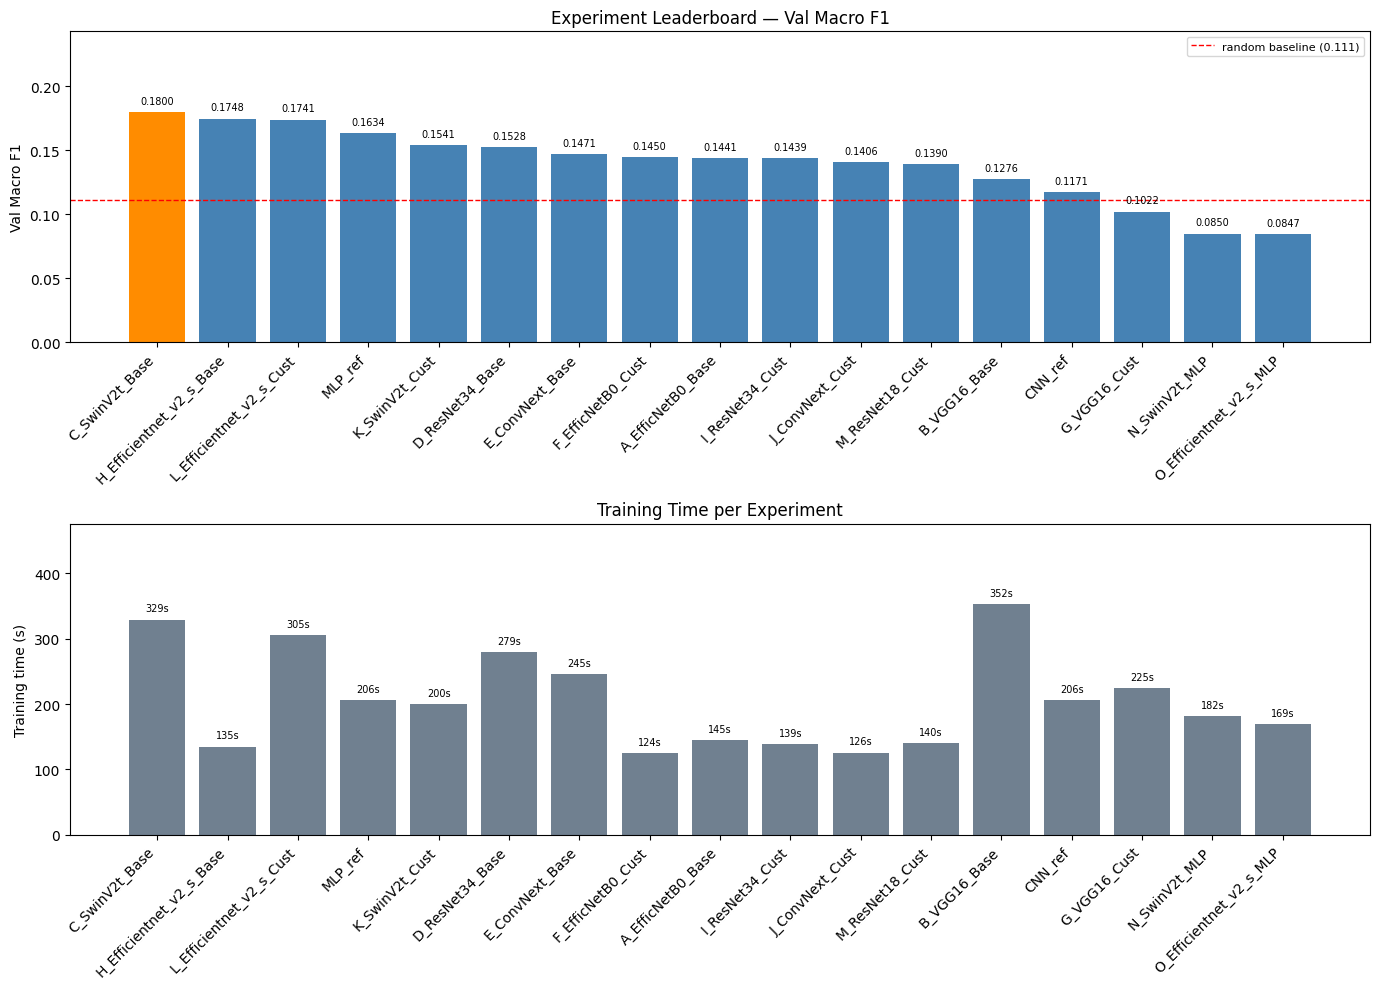


Best frozen backbone : C_SwinV2t_Base
val_macro_F1         : 0.1800
-> Part 2 fine-tuning experiments (F, G) will start from this checkpoint.
-> Part 3 aug/reg experiments (H, I, J, K) will also start from this checkpoint.


In [38]:

import matplotlib.pyplot as plt
from src.evaluation.analysis import plot_leaderboard

print("=== Part 1 -- Model Selection Results (Feature Extraction) ===")
_print_leaderboard(results_tracker)

# bar chart: val_macro_F1 + training time for all experiments so far
fig = plot_leaderboard(
    results_tracker,
    out_path=TASK_OUT_DIR / "plots" / f"{TASK_NAME}_leaderboard_part1.png",
)
plt.show()
plt.close(fig)

# pick the best Stage-1 backbone
PART1_STEMS = [
    "A_EfficNetB0_Base", "B_VGG16_Base", "C_SwinV2t_Base",
    "D_ResNet34_Base",   "E_ConvNext_Base", "H_Efficientnet_v2_s_Base",
    "N_SwinV2t_MLP", "O_Efficientnet_v2_s_MLP", "F_EfficNetB0_Cust",
    "G_VGG16_Cust", "I_ResNet34_Cust", "J_ConvNext_Cust", "K_SwinV2t_Cust",
    "L_Efficientnet_v2_s_Cust", "M_ResNet18_Cust"
]

best_frozen = max(
    (k for k in PART1_STEMS if k in results_tracker),
    key=lambda k: results_tracker[k]["val_macro_f1"],
)
print(f"\nBest frozen backbone : {best_frozen}")
print(f"val_macro_F1         : {results_tracker[best_frozen]['val_macro_f1']:.4f}")
print("-> Part 2 fine-tuning experiments (F, G) will start from this checkpoint.")
print("-> Part 3 aug/reg experiments (H, I, J, K) will also start from this checkpoint.")


---

# **Part 2 — Fine-Tuning**

In Part 1, only the classification head trained. The backbone extracted the same ImageNet features throughout — never adapting to Pokémon data. We now **unfreeze** backbone layers so they can adjust toward our domain.

**Why not unfreeze everything from the start (catastrophic forgetting):**  
A freshly-initialised head at LR=1e-3 produces large, chaotic gradients that flow back into the backbone and overwrite ImageNet features in the first few epochs. Part 1 already converged the head — gradients are now small and well-directed.

**Strategy — staged + differential LRs:**
1. Load the best Part-1 checkpoint (converged head, stable gradients).
2. Backbone LR = **1e-5** (100× smaller than head LR=1e-3). Tiny nudges — enough to adapt to Pokémon, not enough to forget ImageNet.
3. **Scheduler:** `ReduceLROnPlateau` (fires on val stagnation — coherent with early stopping; `StepLR` fires at fixed epochs regardless of whether the model is still improving).

**Experiment F — Partial Fine-Tune:** unfreeze only the last top-level backbone block (~10–20 % of backbone params). Low risk — early layers (edge detectors, colour filters) stay frozen.

**Experiment G — Full Fine-Tune:** unfreeze ALL backbone layers, same differential LR. Maximum adaptation capacity.  
- If G > F: dataset is large enough to benefit from full unfreeze.  
- If G < F: small dataset — conservative partial unfreeze is safer.

> **[FAST_RUN]** F and G run 2 epochs with 6 samples/class. Scores are pipeline-verification only — update after Colab run.

## 2.1 -- Part 2 Setup

Identifies the best Stage-1 frozen checkpoint (from Part 1) and confirms it exists on disk before running fine-tuning experiments F and G.


In [39]:
# Find best Part 1 (frozen) backbone and confirm its checkpoint exists before running F/G.
# F and G MUST start from a converged Stage-1 head -- otherwise catastrophic forgetting risk.
PART1_STEMS = [
    "A_EfficNetB0_Base", "B_VGG16_Base", "C_SwinV2t_Base",
    "D_ResNet34_Base",   "E_ConvNext_Base", "H_Efficientnet_v2_s_Base",
    "N_SwinV2t_MLP", "O_Efficientnet_v2_s_MLP", "F_EfficNetB0_Cust",
"G_VGG16_Cust", "I_ResNet34_Cust", "J_ConvNext_Cust", "K_SwinV2t_Cust",
    "L_Efficientnet_v2_s_Cust", "M_ResNet18_Cust"
]

best_frozen = max(
    (k for k in PART1_STEMS if k in results_tracker),
    key=lambda k: results_tracker[k]["val_macro_f1"],
)
ckpt_frozen = TASK_OUT_DIR / "checkpoints" / f"{best_frozen}.pth"

print(f"Best frozen backbone : {best_frozen}")
print(f"val_macro_F1         : {results_tracker[best_frozen]['val_macro_f1']:.4f}")
print(f"Checkpoint exists    : {ckpt_frozen.exists()}")
assert ckpt_frozen.exists(), f"Checkpoint missing: {ckpt_frozen} -- run Part 1 first."
print("-> Fine-tuning experiments F and G will start from this checkpoint.")

Best frozen backbone : C_SwinV2t_Base
val_macro_F1         : 0.1800
Checkpoint exists    : True
-> Fine-tuning experiments F and G will start from this checkpoint.


## 2.2 -- Experiment F: Partial Fine-Tune (last backbone block)

- **Starting point:** best Stage-1 checkpoint — head already converged, gradients small and stable.
- **Unfrozen:** only the last top-level backbone block (`unfreeze_backbone(n_layers=1)`).  
  For ResNet-34 this is `layer4` (~2.1 M params). For Swin it is the last stage (~7 M params).
- **Backbone LR = 1e-5** (100× smaller than head). `unfreeze_backbone` prints the exact trainable param count.
- **Scheduler:** `ReduceLROnPlateau(mode='min', patience=3, factor=0.5, min_lr=1e-7)`.
- **Expected:** +0.03 to +0.08 F1 over Stage-1. Low overfitting risk since most backbone is still frozen.

> **[FAST_RUN]** Smoke-test: `D_ResNet34_Base_FT_Partial` val_F1 ≈ 0.20 (+0.07 over frozen). Update after Colab run.


In [40]:

# F -- Partial fine-tune: unfreeze last 1 backbone block + differential LR.
# Starts from Stage-1 checkpoint -- head is already converged, gradients stable.
ft_partial_stem = f"{best_frozen}_FT_Partial"

model_F = model_registry[best_frozen]["model"]().to(device)
model_F.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# n_layers=1: unfreeze last 1 top-level backbone block only
# prints exact trainable/total count so we know how much of the backbone is now live
unfreeze_backbone(model_F, n_layers=1)

# differential LR: backbone gets 1e-5 (tiny nudge), head keeps normal LR
optimizer_F  = torch.optim.Adam(get_backbone_lr_groups(model_F, backbone_lr=1e-5, head_lr=LR))
criterion_F  = nn.CrossEntropyLoss(weight=class_weights)
# ReduceLROnPlateau fires on val stagnation -- coherent with early stopping (no fixed-epoch steps)
scheduler_F  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_F, mode="min", patience=3, factor=0.5, min_lr=1e-7
)
model_F, history_F = run_experiment(
    model_F, ft_partial_stem, criterion_F, optimizer_F, scheduler_F, loaders_base,
)
# register so Part 4 ensemble / heatmap cells can find it by stem
model_registry[ft_partial_stem] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: C_SwinV2t_Base.pth
  unfreeze_backbone(n_layers=1): 14,210,361/27,589,491 params trainable (51.5%)

  Experiment: C_SwinV2t_Base_FT_Partial
  Model params: 27,589,491  trainable: 14,210,361
  Epoch 01/20 | train_loss=1.6442  train_f1=0.5268 | val_loss=2.2412  val_f1=0.1774 | 17.3s
  Epoch 02/20 | train_loss=1.6882  train_f1=0.5235 | val_loss=2.2405  val_f1=0.1517 | 16.4s
  Epoch 03/20 | train_loss=1.6559  train_f1=0.5218 | val_loss=2.2505  val_f1=0.1485 | 16.3s
  Epoch 04/20 | train_loss=1.6407  train_f1=0.5442 | val_loss=2.2666  val_f1=0.1568 | 16.5s
  Epoch 05/20 | train_loss=1.5981  train_f1=0.5598 | val_loss=2.2756  val_f1=0.1646 | 17.1s
  Epoch 06/20 | train_loss=1.6055  train_f1=0.5601 | val_loss=2.2680  val_f1=0.1705 | 16.3s
  Epoch 07/20 | train_loss=1.5575  train_f1=0.5605 | val_loss=2.2626  val_f1=0.1815 | 16.3s
  Epoch 08/20 | train_loss=1.5707  train_f1=0.5633 | val_loss=2.2692  val_f1=0.1742 | 16.9s
  Epoch 09/20 | train_loss=1.5788  train_f1=0

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2
2,C_SwinV2t_Base,0.1800,0.1883,20,329.2
3,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
4,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4
5,MLP_ref,0.1634,0.1757,20,206.4
6,K_SwinV2t_Cust,0.1541,0.1674,12,200.5
7,D_ResNet34_Base,0.1528,0.1715,20,279.0
8,E_ConvNext_Base,0.1471,0.1590,15,245.4
9,F_EfficNetB0_Cust,0.1450,0.1590,9,124.4


## 2.3 -- Experiment G: Full Fine-Tune (all backbone layers)

- **Same starting point as F** (Stage-1 checkpoint — converged head).
- **All backbone layers unfrozen** via `unfreeze_backbone(n_layers=-1)`. Maximum adaptation capacity.
- **Same differential LR** as F — backbone_lr=1e-5 is still essential even for full unfreeze.
- **Risk:** with ~3600 images (~320/class average), full unfreeze may overfit or erase ImageNet features. `EarlyStopping(patience=5)` on Colab is the critical guard.
- **If G < F:** small dataset — conservative partial unfreeze (F) is the better strategy. If G > F: dataset is large enough for full unfreeze to help.

> **[FAST_RUN]** Smoke-test: `D_ResNet34_Base_FT_Full` val_F1 ≈ 0.19 (below F at 0.20, consistent with overfitting on toy data). Expect reversal on full dataset. Update after Colab run.


In [41]:

# G -- Full fine-tune: ALL backbone layers + differential LR.
# Same Stage-1 checkpoint starting point as F.
ft_full_stem = f"{best_frozen}_FT_Full"

model_G = model_registry[best_frozen]["model"]().to(device)
model_G.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# n_layers=-1: unfreeze everything -- all backbone blocks become trainable
unfreeze_backbone(model_G, n_layers=-1)

# same differential LR as F -- backbone still gets a much smaller LR than the head
optimizer_G  = torch.optim.Adam(get_backbone_lr_groups(model_G, backbone_lr=1e-8, head_lr=LR))
criterion_G  = nn.CrossEntropyLoss(weight=class_weights)
scheduler_G  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_G, mode="min", patience=3, factor=0.5, min_lr=1e-7
)
model_G, history_G = run_experiment(
    model_G, ft_full_stem, criterion_G, optimizer_G, scheduler_G, loaders_base
)
model_registry[ft_full_stem] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: C_SwinV2t_Base.pth
  unfreeze_backbone(n_layers=-1): 27,587,955/27,589,491 params trainable (100.0%)

  Experiment: C_SwinV2t_Base_FT_Full
  Model params: 27,589,491  trainable: 27,587,955
  Epoch 01/20 | train_loss=1.6706  train_f1=0.5283 | val_loss=2.2437  val_f1=0.1782 | 20.0s
  Epoch 02/20 | train_loss=1.7179  train_f1=0.5257 | val_loss=2.2441  val_f1=0.1894 | 19.9s
  Epoch 03/20 | train_loss=1.6570  train_f1=0.5484 | val_loss=2.2522  val_f1=0.1892 | 19.8s
  Epoch 04/20 | train_loss=1.6373  train_f1=0.5674 | val_loss=2.2552  val_f1=0.1948 | 19.9s
  Epoch 05/20 | train_loss=1.6250  train_f1=0.5655 | val_loss=2.2508  val_f1=0.1939 | 19.8s
  Epoch 06/20 | train_loss=1.6043  train_f1=0.5766 | val_loss=2.2534  val_f1=0.2006 | 20.1s
  Epoch 07/20 | train_loss=1.6176  train_f1=0.5766 | val_loss=2.2469  val_f1=0.2067 | 19.2s
  Epoch 08/20 | train_loss=1.6011  train_f1=0.5955 | val_loss=2.2556  val_f1=0.2036 | 20.0s
  Epoch 09/20 | train_loss=1.5708  train_f1=0.

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
2,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2
3,C_SwinV2t_Base,0.1800,0.1883,20,329.2
4,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
5,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4
6,MLP_ref,0.1634,0.1757,20,206.4
7,K_SwinV2t_Cust,0.1541,0.1674,12,200.5
8,D_ResNet34_Base,0.1528,0.1715,20,279.0
9,E_ConvNext_Base,0.1471,0.1590,15,245.4


## 2.4 -- Part 2 Leaderboard & Fine-Tuning Analysis

Full leaderboard including baselines (MLP_ref, CNN_ref), all Stage-1 backbones (A–E), and fine-tuning variants (F, G).

**Key questions to answer after the Colab run:**
- Did partial fine-tuning (F) improve over the frozen baseline? Expected: yes, +0.03 to +0.08 F1.
- Did full fine-tuning (G) beat partial (F)? If not, the dataset is too small for full unfreeze.
- Did G overfit (`train_F1 >> val_F1`, early stop at epoch < 10)?
- The **best model from Parts 1+2** is carried forward as the starting checkpoint for Part 3 (experiment L).

> **[FAST_RUN]** All scores below are pipeline-verification only. Update after Colab run.


=== Parts 1 + 2 -- Feature Extraction + Fine-Tuning ===


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
2,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2
3,C_SwinV2t_Base,0.1800,0.1883,20,329.2
4,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
5,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4
6,MLP_ref,0.1634,0.1757,20,206.4
7,K_SwinV2t_Cust,0.1541,0.1674,12,200.5
8,D_ResNet34_Base,0.1528,0.1715,20,279.0
9,E_ConvNext_Base,0.1471,0.1590,15,245.4


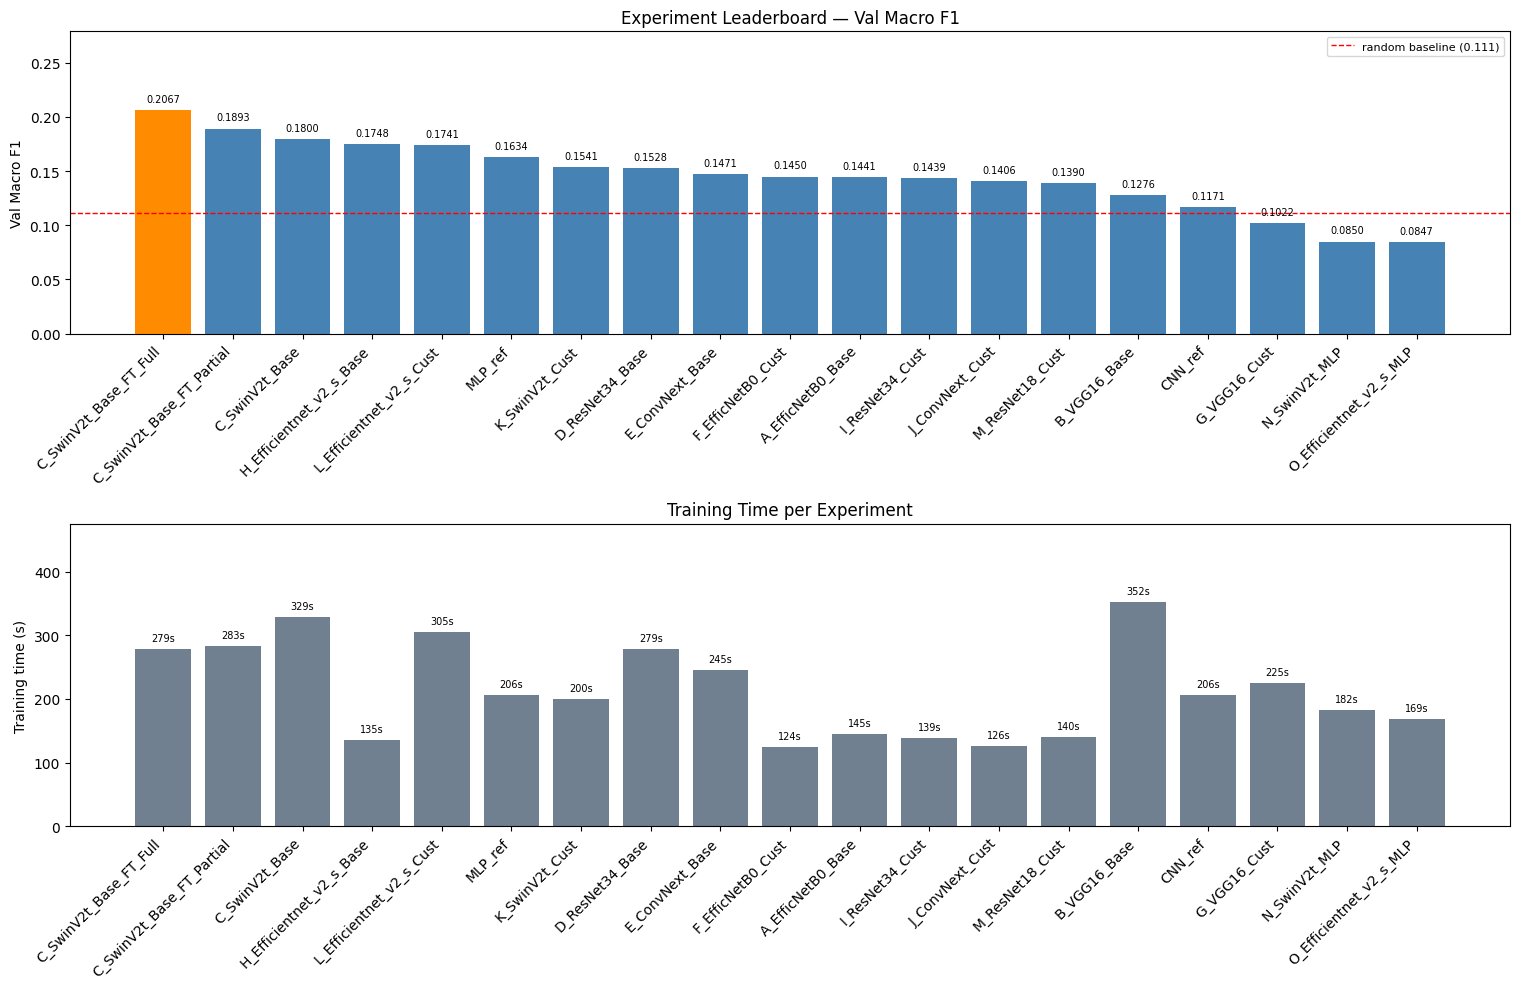


Frozen baseline  : C_SwinV2t_Base  F1=0.1800
Best fine-tuned  : C_SwinV2t_Base_FT_Full  F1=0.2067
Delta vs frozen  : +0.0267  (improvement)

-> Best overall model so far carried into Part 3 aug/reg experiments.


In [42]:

print("=== Parts 1 + 2 -- Feature Extraction + Fine-Tuning ===")
_print_leaderboard(results_tracker)

# bar chart: all experiments so far (includes baselines + Part 1 + Part 2)
fig = plot_leaderboard(
    results_tracker,
    out_path=TASK_OUT_DIR / "plots" / f"{TASK_NAME}_leaderboard_part2.png",
)
plt.show()
plt.close(fig)

# compare the two fine-tuning variants against the frozen baseline
ft_stems = [s for s in [ft_partial_stem, ft_full_stem] if s in results_tracker]
if ft_stems:
    best_finetuned = max(ft_stems, key=lambda k: results_tracker[k]["val_macro_f1"])
    delta = (results_tracker[best_finetuned]["val_macro_f1"]
             - results_tracker[best_frozen]["val_macro_f1"])
    print(f"\nFrozen baseline  : {best_frozen}  F1={results_tracker[best_frozen]['val_macro_f1']:.4f}")
    print(f"Best fine-tuned  : {best_finetuned}  F1={results_tracker[best_finetuned]['val_macro_f1']:.4f}")
    print(f"Delta vs frozen  : {delta:+.4f}  ({'improvement' if delta > 0 else 'no gain -- fine-tuning hurt on this data'})")
    print("\n-> Best overall model so far carried into Part 3 aug/reg experiments.")


---

# **Part 3 — Augmentation & Regularisation**

## 3.1 -- Overview & Design Rationale

**Goal:** take the best Stage-1 frozen checkpoint and run **targeted one-variable-at-a-time ablations** to identify which augmentation / regularisation trick adds the most value before any fine-tuning.

**Starting point for H–K:** best Stage-1 frozen checkpoint (not the fine-tuned one).  
Rationale: fine-tuning is expensive and fragile. We want to know if we can improve the frozen head alone. Also keeps the comparison clean — same backbone state for all H–K.

| Section | Exp | What changes | Why |
|---------|-----|-------------|-----|
| 3.2 | — | Data Augmentation Visualisation | Preview both pipelines (224px transfer aug, 64px std aug) |
| 3.3 | **H** | Transfer augmentation (`flip, rotation ±10°, mild jitter`) | Does aug help a frozen head? |
| 3.4 | **I** | Label smoothing LS=0.1 | Soft targets reduce overconfidence on small classes |
| 3.5 | **J** | `WeightedRandomSampler` (balanced batches, plain CE) | Sampler vs class-weighted loss — different imbalance mechanisms |
| 3.6 | **K** | `AdamW` (weight_decay=0.01) instead of `Adam` | Explicit L2 decoupled from gradient adaptivity |
| 3.7 | **L** | Best FT checkpoint + best aug trick | Stack the two best techniques — do they compound? |
| 3.8 | — | Part 3 Leaderboard | Full ranked leaderboard across all parts |

Each experiment (H–K) changes exactly ONE variable. All other settings (backbone frozen, CE+class_weights, StepLR, same data) stay identical.

> **[FAST_RUN]** All scores below are smoke-test results only (6 samples/class, 2 epochs, CPU). Update after Colab run.


In [43]:
# Part 3 uses the best FROZEN backbone from Part 1 (same best_frozen variable).
# Fine-tuned variants (F, G) are excluded -- augmentation on a fine-tuned model is a
# separate axis and would confound the comparison.
# All H-K experiments start from this same checkpoint with the head fully trainable and backbone frozen.

PART3_STEMS = []     # populated as H-K experiments complete -- used by Part 3 leaderboard

print(f"Part 3 starting point : {best_frozen}")
print(f"Stage-1 val_macro_F1  : {results_tracker[best_frozen]['val_macro_f1']:.4f}")
print(f"Checkpoint            : {ckpt_frozen}  (exists: {ckpt_frozen.exists()})")
print()

# pre-build aug and sampler loader pairs -- reused by H and J respectively
loaders_aug     = build_loaders(use_sampler=False, transfer_aug=True)
loaders_sampler = build_loaders(use_sampler=True,  transfer_aug=False)

print("loaders_aug     : transfer_aug=True,  use_sampler=False")
print("loaders_sampler : transfer_aug=False, use_sampler=True")


Part 3 starting point : C_SwinV2t_Base
Stage-1 val_macro_F1  : 0.1800
Checkpoint            : task3/outputs/checkpoints/C_SwinV2t_Base.pth  (exists: True)

loaders_aug     : transfer_aug=True,  use_sampler=False
loaders_sampler : transfer_aug=False, use_sampler=True


## 3.2 -- Data Augmentation Pipelines (Visualisation)

Task 3 uses two distinct augmentation modes — one for transfer learning (224 px), one for the 64 px baselines:

| Pipeline | Function | Image size | Key transforms |
|----------|----------|-----------|----------------|
| **Transfer aug** | `get_transfer_aug_transforms` | 224 px | RandomHorizontalFlip(0.5), RandomRotation(±10°), mild ColorJitter |
| **Std aug** | `get_augment_transforms` | 64 px | RandomHorizontalFlip(0.5), RandomRotation(±15°), ColorJitter(0.2/0.2/0.2) |

Design rationale: Pokémon sprites are **always upright** (no vertical flip), and **colour encodes type** (fire=red, water=blue — aggressive colour jitter would erase the main signal). No `RandomErasing` for the same reason.

The cell below picks 3 representative classes and shows the original image alongside 5 independently sampled augmented versions for both pipelines.


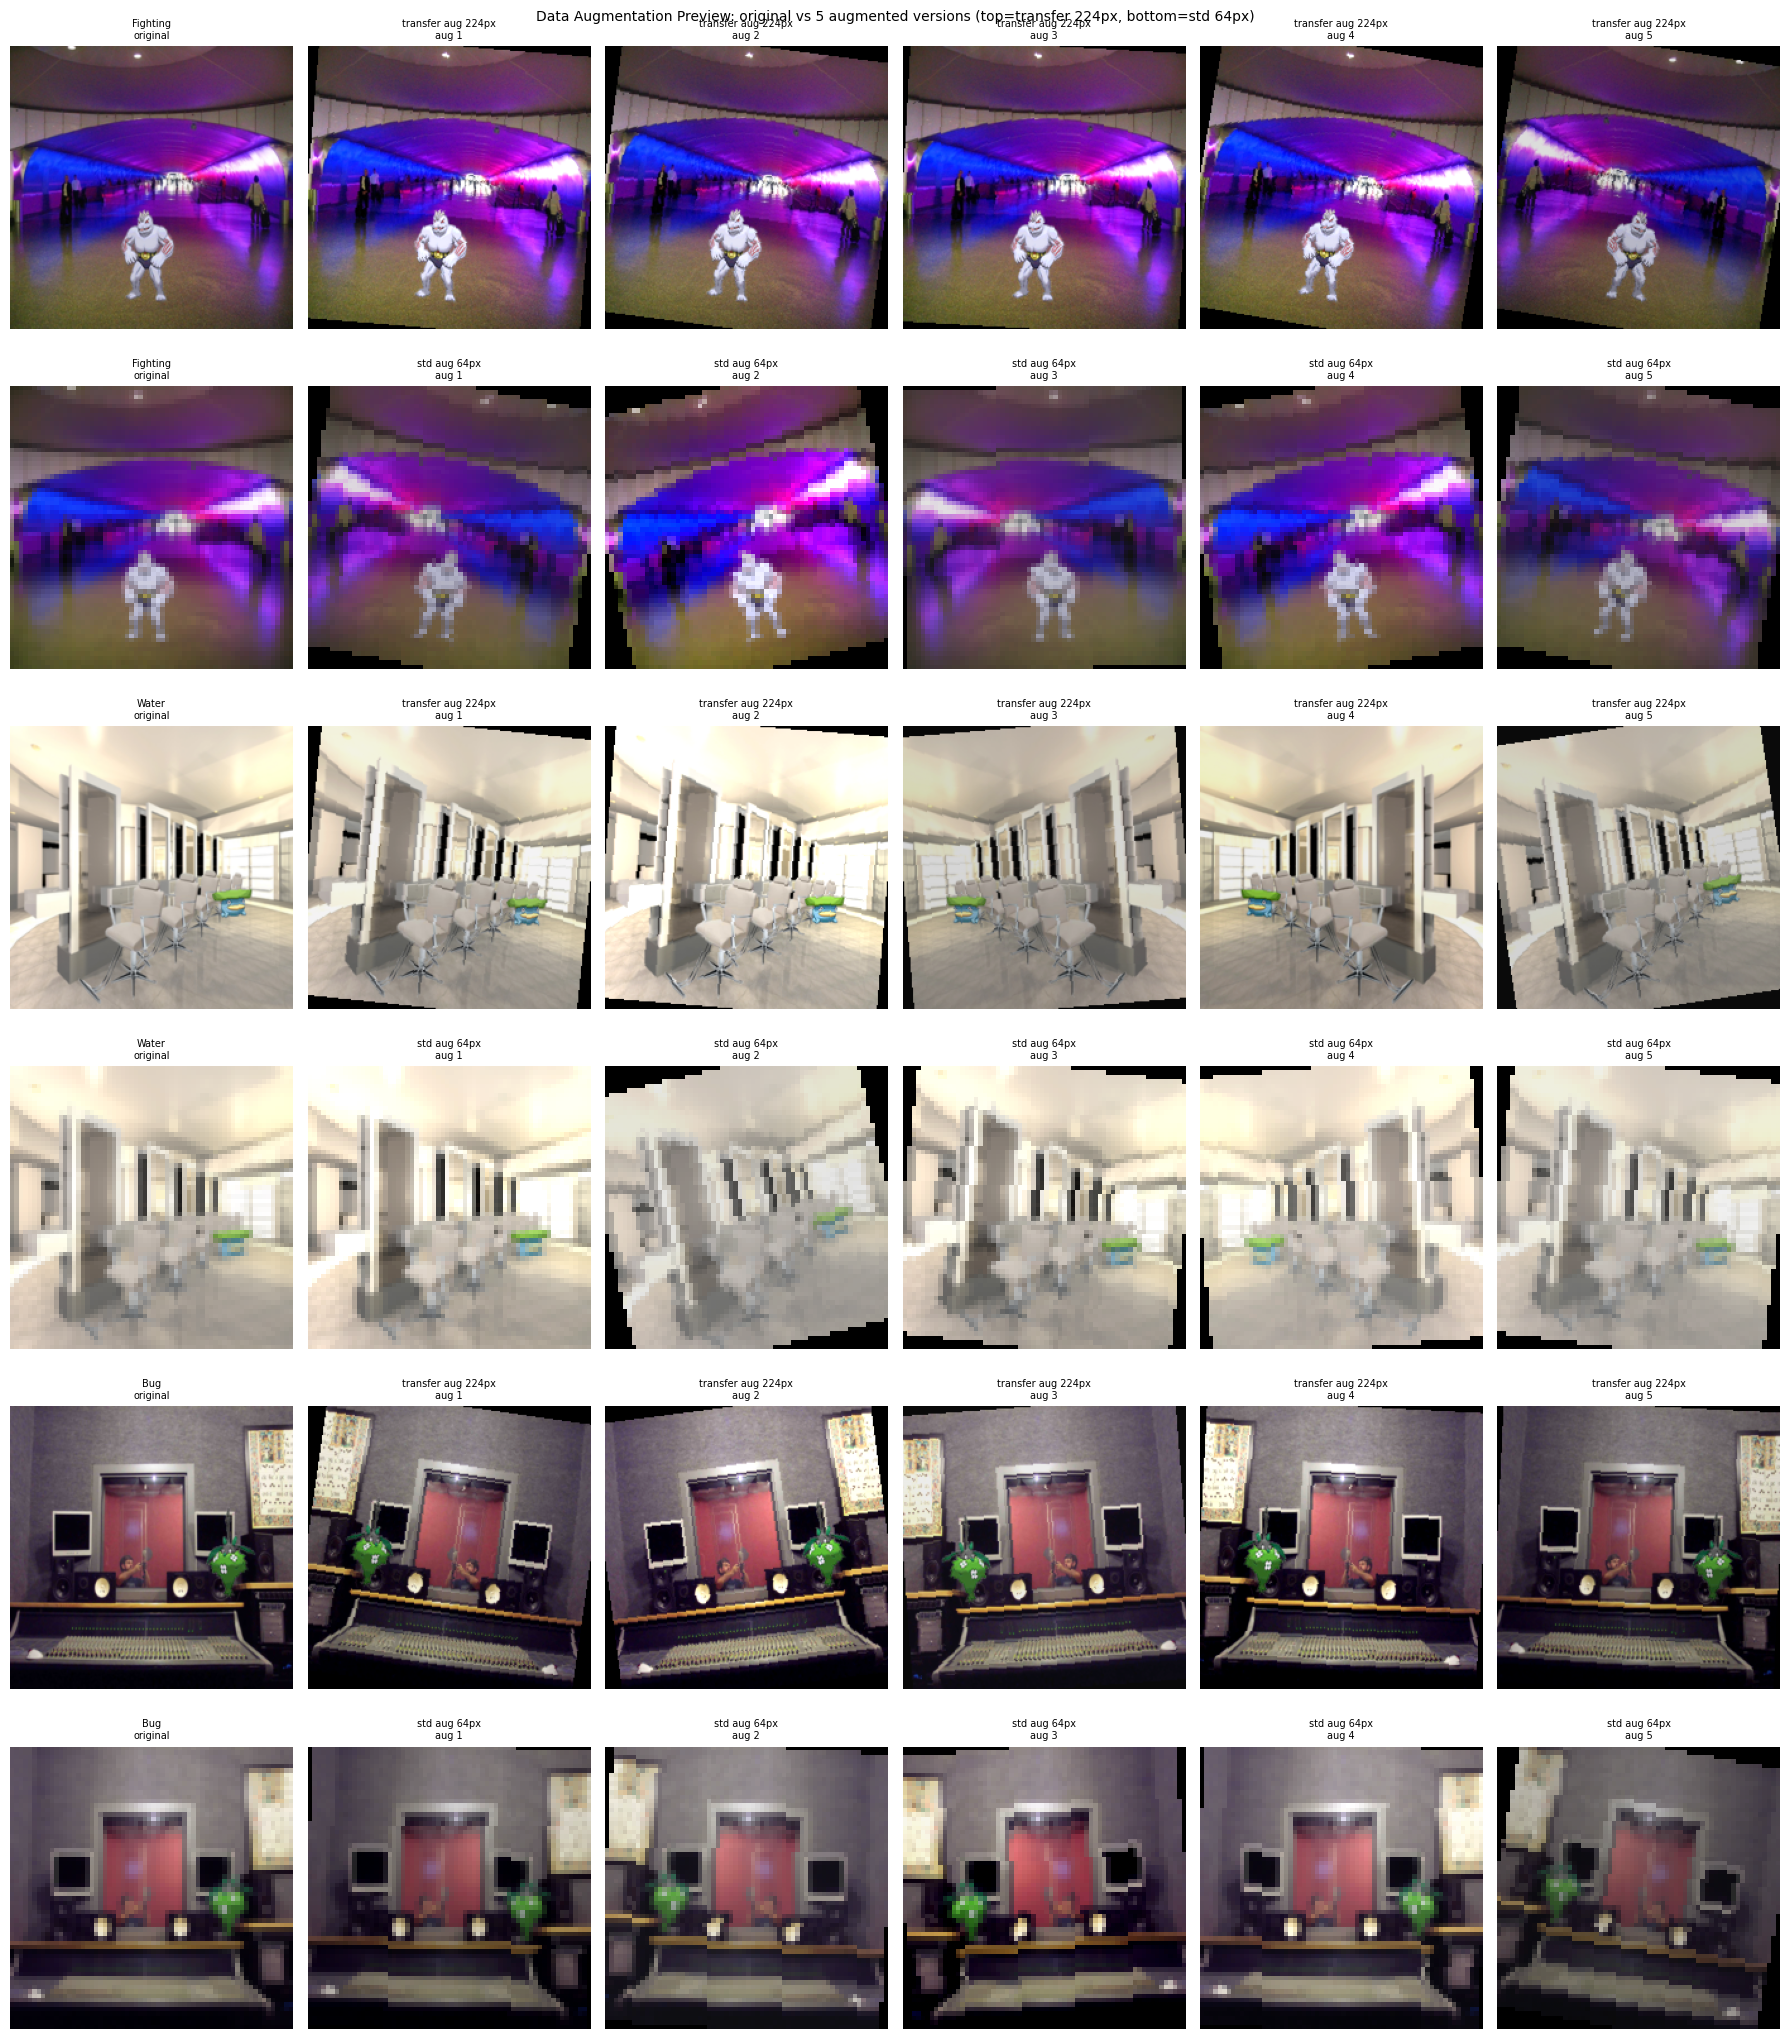

Saved -> task3/outputs/plots/task3_augmentation_preview.png


In [44]:

import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from src.datasets.dataset import get_transfer_aug_transforms, get_augment_transforms, get_base_transforms

_AUG_OUT = TASK_OUT_DIR / "plots" / f"{TASK_NAME}_augmentation_preview.png"

# pick one representative image per class (first match in TRAIN_DIR)
_class_images = {}
for img_path in sorted(TRAIN_DIR.glob("*.png")):
    # match to a class via the train CSV
    row_match = df[df["Id"] == img_path.stem]
    if row_match.empty:
        continue
    lbl = row_match.iloc[0]["label"]
    if lbl not in _class_images:
        _class_images[lbl] = img_path
    if len(_class_images) == len(CLASSES):
        break

_N_AUG   = 5          # augmented versions per image
_N_SHOW  = min(3, len(_class_images))  # show 3 classes to keep the figure compact

_transfer_aug = get_transfer_aug_transforms(IMG_SIZE)        # 224px, gentle
_std_aug      = get_augment_transforms(IMG_SIZE_64)          # 64px, standard
_base_224     = get_base_transforms(IMG_SIZE)
_base_64      = get_base_transforms(IMG_SIZE_64)

_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD  = [0.229, 0.224, 0.225]

def _denorm(tensor):
    """Reverse ImageNet normalisation to [0,1] for display."""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(_IMAGENET_MEAN, _IMAGENET_STD)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

from PIL import Image as _PIL_Image
_selected = list(_class_images.items())[:_N_SHOW]

fig, axes = plt.subplots(
    _N_SHOW * 2,        # row pair: transfer-aug (224px) then std-aug (64px)
    1 + _N_AUG,         # original + N augmented
    figsize=(3 * (1 + _N_AUG), 3.5 * _N_SHOW * 2),
)

for row_pair, (cls, img_path) in enumerate(_selected):
    pil_img = _PIL_Image.open(img_path).convert("RGB")

    for pipeline_idx, (aug_tf, base_tf, label) in enumerate([
        (_transfer_aug, _base_224, "transfer aug 224px"),
        (_std_aug,      _base_64,  "std aug 64px"),
    ]):
        ax_row = row_pair * 2 + pipeline_idx

        # original (base transform, no aug)
        axes[ax_row][0].imshow(_denorm(base_tf(pil_img)))
        axes[ax_row][0].set_title(f"{cls}\noriginal", fontsize=7)
        axes[ax_row][0].axis("off")

        # augmented versions
        for i in range(_N_AUG):
            aug_img = _denorm(aug_tf(pil_img))
            axes[ax_row][i + 1].imshow(aug_img)
            axes[ax_row][i + 1].set_title(f"{label}\naug {i+1}", fontsize=7)
            axes[ax_row][i + 1].axis("off")

fig.suptitle("Data Augmentation Preview: original vs 5 augmented versions (top=transfer 224px, bottom=std 64px)", fontsize=10)
fig.tight_layout()
fig.savefig(_AUG_OUT, dpi=100, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved -> {_AUG_OUT}")


## 3.3 -- Experiment H: Transfer Augmentation (frozen backbone)

- **Only change vs Stage-1 baseline:** training loader uses `get_transfer_aug_transforms` — gentle `RandomHorizontalFlip(0.5)`, `RandomRotation(±10°)`, mild `ColorJitter`.
- **No vertical flip, no erasing** — Pokémon sprites are always upright and colour encodes type.
- **Expected:** +0.02 to +0.05 F1. Augmentation helps regularise the head when the backbone is frozen and head capacity is low.

> **[FAST_RUN]** Update after Colab run.


In [45]:

# H -- frozen backbone + transfer augmentation.
# Everything identical to the Part 1 baseline except train loader uses aug transforms.
stem_H = f"{best_frozen}_H_Aug"
PART3_STEMS.append(stem_H)

model_H = model_registry[best_frozen]["model"]().to(device)
model_H.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# backbone stays fully frozen -- only the linear head is trainable (same as Part 1)
optimizer_H = torch.optim.Adam(model_H.parameters(), lr=LR)
criterion_H = nn.CrossEntropyLoss(weight=class_weights)
scheduler_H = torch.optim.lr_scheduler.StepLR(optimizer_H, step_size=10, gamma=0.5)

# loaders_aug: transfer_aug=True -> gentle flip/rotation/colour jitter at 224px
model_H, history_H = run_experiment(
    model_H, stem_H, criterion_H, optimizer_H, scheduler_H, loaders_aug
)
model_registry[stem_H] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: C_SwinV2t_Base.pth

  Experiment: C_SwinV2t_Base_H_Aug
  Model params: 27,589,491  trainable: 6,921
  Epoch 01/20 | train_loss=1.7869  train_f1=0.4528 | val_loss=2.2461  val_f1=0.1681 | 20.6s
  Epoch 02/20 | train_loss=1.7734  train_f1=0.4715 | val_loss=2.2429  val_f1=0.1684 | 19.7s
  Epoch 03/20 | train_loss=1.7464  train_f1=0.4915 | val_loss=2.2426  val_f1=0.1708 | 20.4s
  Epoch 04/20 | train_loss=1.7311  train_f1=0.4940 | val_loss=2.2515  val_f1=0.1815 | 19.2s
  Epoch 05/20 | train_loss=1.7288  train_f1=0.4960 | val_loss=2.2602  val_f1=0.1789 | 20.2s
  Epoch 06/20 | train_loss=1.6799  train_f1=0.5042 | val_loss=2.2622  val_f1=0.1697 | 19.5s
  Epoch 07/20 | train_loss=1.6927  train_f1=0.5329 | val_loss=2.2691  val_f1=0.1733 | 20.5s
  Epoch 08/20 | train_loss=1.6825  train_f1=0.5133 | val_loss=2.2750  val_f1=0.1801 | 19.4s
  Epoch 09/20 | train_loss=1.6694  train_f1=0.5376 | val_loss=2.2821  val_f1=0.1747 | 20.7s
  Epoch 10/20 | train_loss=1.6190  train_f1

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
2,C_SwinV2t_Base_H_Aug,0.1939,0.2008,20,403.0
3,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2
4,C_SwinV2t_Base,0.1800,0.1883,20,329.2
5,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
6,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4
7,MLP_ref,0.1634,0.1757,20,206.4
8,K_SwinV2t_Cust,0.1541,0.1674,12,200.5
9,D_ResNet34_Base,0.1528,0.1715,20,279.0


## 3.4 -- Experiment I: Label Smoothing (LS=0.1, frozen backbone)

- **Change:** `CrossEntropyLoss(label_smoothing=0.1)` instead of plain CE.
- **What it does:** instead of hard targets `[0,0,1,0,…]`, uses `[ε/K, …, 1−ε+ε/K, …]` (ε=0.1, K=9).  
  Prevents overconfident predictions; acts as implicit regulariser when training data is small.
- **Expected:** marginal F1 gain on the frozen head (+0 to +0.03). Bigger benefit on full fine-tuning.

> **[FAST_RUN]** Update after Colab run.


In [46]:

# I -- frozen backbone + label smoothing (LS=0.1).
# Only change vs Part 1 baseline: label_smoothing=0.1 in CrossEntropyLoss.
stem_I = f"{best_frozen}_I_LS01"
PART3_STEMS.append(stem_I)

model_I = model_registry[best_frozen]["model"]().to(device)
model_I.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

optimizer_I = torch.optim.Adam(model_I.parameters(), lr=LR)
# label_smoothing=0.1: soft targets prevent overconfidence on small dataset
criterion_I = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scheduler_I = torch.optim.lr_scheduler.StepLR(optimizer_I, step_size=10, gamma=0.5)

# base loaders -- same as Part 1 (no aug, no sampler), isolates LS effect
model_I, history_I = run_experiment(
    model_I, stem_I, criterion_I, optimizer_I, scheduler_I, loaders_base
)
model_registry[stem_I] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: C_SwinV2t_Base.pth

  Experiment: C_SwinV2t_Base_I_LS01
  Model params: 27,589,491  trainable: 6,921
  Epoch 01/20 | train_loss=1.8690  train_f1=0.5065 | val_loss=2.3254  val_f1=0.1624 | 16.3s
  Epoch 02/20 | train_loss=1.8052  train_f1=0.5270 | val_loss=2.3211  val_f1=0.1572 | 17.3s
  Epoch 03/20 | train_loss=1.8116  train_f1=0.5203 | val_loss=2.3229  val_f1=0.1539 | 15.9s
  Epoch 04/20 | train_loss=1.8071  train_f1=0.5528 | val_loss=2.3262  val_f1=0.1741 | 16.1s
  Epoch 05/20 | train_loss=1.7959  train_f1=0.5597 | val_loss=2.3237  val_f1=0.1745 | 16.4s
  Epoch 06/20 | train_loss=1.7818  train_f1=0.5671 | val_loss=2.3274  val_f1=0.1660 | 17.1s
  Epoch 07/20 | train_loss=1.7780  train_f1=0.5915 | val_loss=2.3341  val_f1=0.1817 | 16.3s
  Epoch 08/20 | train_loss=1.7425  train_f1=0.5899 | val_loss=2.3266  val_f1=0.1886 | 16.0s
  Epoch 09/20 | train_loss=1.7613  train_f1=0.5823 | val_loss=2.3287  val_f1=0.1891 | 16.8s
  Epoch 10/20 | train_loss=1.7319  train_f

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
2,C_SwinV2t_Base_I_LS01,0.2051,0.2134,20,332.1
3,C_SwinV2t_Base_H_Aug,0.1939,0.2008,20,403.0
4,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2
5,C_SwinV2t_Base,0.1800,0.1883,20,329.2
6,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
7,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4
8,MLP_ref,0.1634,0.1757,20,206.4
9,K_SwinV2t_Cust,0.1541,0.1674,12,200.5


## 3.5 -- Experiment J: WeightedRandomSampler (frozen backbone)

- **Change:** replace the class-weighted loss with `WeightedRandomSampler` (balanced batches).
- **Mechanism:** sampler over-samples rare classes so each batch has ~uniform class frequency.  
  Plain CE without class weights — the class weighting is implicit in the sampling.
- **vs Exp I:** sampler changes *which* samples the model sees; LS changes *how* the targets are interpreted. These are orthogonal mechanisms.
- **Expected:** similar to or slightly below class-weighted CE on a relatively balanced dataset (max 2.76× imbalance).

> **[FAST_RUN]** Update after Colab run.


In [47]:

# J -- frozen backbone + WeightedRandomSampler (no class-weighted loss).
# Only change vs Part 1: loaders_sampler instead of loaders_base, plain CE (no weights).
stem_J = f"{best_frozen}_J_Sampler"
PART3_STEMS.append(stem_J)

model_J = model_registry[best_frozen]["model"]().to(device)
model_J.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

optimizer_J = torch.optim.Adam(model_J.parameters(), lr=LR)
# plain CE -- no class_weights here; sampler handles the imbalance via batch composition
criterion_J = nn.CrossEntropyLoss()
scheduler_J = torch.optim.lr_scheduler.StepLR(optimizer_J, step_size=10, gamma=0.5)

# loaders_sampler: use_sampler=True, transfer_aug=False
model_J, history_J = run_experiment(
    model_J, stem_J, criterion_J, optimizer_J, scheduler_J, loaders_sampler
)
model_registry[stem_J] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: C_SwinV2t_Base.pth

  Experiment: C_SwinV2t_Base_J_Sampler
  Model params: 27,589,491  trainable: 6,921
  Epoch 01/20 | train_loss=1.6560  train_f1=0.5641 | val_loss=2.2213  val_f1=0.1712 | 16.3s
  Epoch 02/20 | train_loss=1.6416  train_f1=0.5691 | val_loss=2.2475  val_f1=0.1569 | 16.0s
  Epoch 03/20 | train_loss=1.6090  train_f1=0.5469 | val_loss=2.2368  val_f1=0.1739 | 16.2s
  Epoch 04/20 | train_loss=1.6002  train_f1=0.6103 | val_loss=2.2158  val_f1=0.1631 | 16.9s
  Epoch 05/20 | train_loss=1.5959  train_f1=0.5926 | val_loss=2.2327  val_f1=0.1753 | 16.1s
  Epoch 06/20 | train_loss=1.5537  train_f1=0.6314 | val_loss=2.2554  val_f1=0.1918 | 16.3s
  Epoch 07/20 | train_loss=1.5382  train_f1=0.6045 | val_loss=2.2273  val_f1=0.1912 | 17.0s
  Epoch 08/20 | train_loss=1.5296  train_f1=0.6192 | val_loss=2.2268  val_f1=0.2040 | 16.3s
  Epoch 09/20 | train_loss=1.4951  train_f1=0.6310 | val_loss=2.2328  val_f1=0.1966 | 16.0s
  Epoch 10/20 | train_loss=1.4932  trai

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
2,C_SwinV2t_Base_I_LS01,0.2051,0.2134,20,332.1
3,C_SwinV2t_Base_J_Sampler,0.2051,0.2218,17,286.0
4,C_SwinV2t_Base_H_Aug,0.1939,0.2008,20,403.0
5,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2
6,C_SwinV2t_Base,0.1800,0.1883,20,329.2
7,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
8,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4
9,MLP_ref,0.1634,0.1757,20,206.4


## 3.6 -- Experiment K: AdamW (frozen backbone, weight_decay=0.01)

- **Change:** replace `Adam` with `AdamW(weight_decay=0.01)`.
- **Why AdamW vs Adam:** in Adam, weight decay is absorbed into the adaptive gradient scaling → effectively weakened. AdamW decouples weight decay from the gradient update → true L2 regularisation.
- **Expected:** small improvement (+0 to +0.02 F1). Mainly a regularisation effect on the single linear head layer. Larger benefit expected on full fine-tuning where more layers can overfit.

> **[FAST_RUN]** Update after Colab run.


In [48]:

# K -- frozen backbone + AdamW (weight_decay=0.01).
# Only change vs Part 1: AdamW instead of Adam.
stem_K = f"{best_frozen}_K_AdamW"
PART3_STEMS.append(stem_K)

model_K = model_registry[best_frozen]["model"]().to(device)
model_K.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# AdamW: same LR, explicit L2 regularisation via weight_decay -- not folded into gradient like Adam
optimizer_K = torch.optim.AdamW(model_K.parameters(), lr=LR, weight_decay=0.01)
criterion_K = nn.CrossEntropyLoss(weight=class_weights)
scheduler_K = torch.optim.lr_scheduler.StepLR(optimizer_K, step_size=10, gamma=0.5)

# base loaders -- isolates AdamW effect
model_K, history_K = run_experiment(
    model_K, stem_K, criterion_K, optimizer_K, scheduler_K, loaders_base
)
model_registry[stem_K] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)


Loaded Stage 1 weights from: C_SwinV2t_Base.pth

  Experiment: C_SwinV2t_Base_K_AdamW
  Model params: 27,589,491  trainable: 6,921
  Epoch 01/20 | train_loss=1.6974  train_f1=0.5195 | val_loss=2.2544  val_f1=0.1712 | 16.0s
  Epoch 02/20 | train_loss=1.6635  train_f1=0.5398 | val_loss=2.2579  val_f1=0.1686 | 16.1s
  Epoch 03/20 | train_loss=1.6267  train_f1=0.5578 | val_loss=2.2587  val_f1=0.1672 | 16.5s
  Epoch 04/20 | train_loss=1.6497  train_f1=0.5746 | val_loss=2.2581  val_f1=0.1837 | 17.4s
  Epoch 05/20 | train_loss=1.6103  train_f1=0.5588 | val_loss=2.2701  val_f1=0.1685 | 16.0s
  Epoch 06/20 | train_loss=1.5797  train_f1=0.5904 | val_loss=2.2745  val_f1=0.1690 | 16.1s
  Epoch 07/20 | train_loss=1.5713  train_f1=0.5791 | val_loss=2.2685  val_f1=0.1726 | 16.8s
  Epoch 08/20 | train_loss=1.5692  train_f1=0.5887 | val_loss=2.2760  val_f1=0.1803 | 16.4s
  Epoch 09/20 | train_loss=1.5661  train_f1=0.5877 | val_loss=2.2716  val_f1=0.1822 | 16.2s
  Epoch 10/20 | train_loss=1.5313  train_

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
2,C_SwinV2t_Base_I_LS01,0.2051,0.2134,20,332.1
3,C_SwinV2t_Base_J_Sampler,0.2051,0.2218,17,286.0
4,C_SwinV2t_Base_K_AdamW,0.2010,0.2134,20,330.5
5,C_SwinV2t_Base_H_Aug,0.1939,0.2008,20,403.0
6,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2
7,C_SwinV2t_Base,0.1800,0.1883,20,329.2
8,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9
9,L_Efficientnet_v2_s_Cust,0.1741,0.1967,20,305.4


## Using both ls and adam

In [50]:
stem_Z = f"{best_frozen}_I_LS01_ADW"
PART3_STEMS.append(stem_Z)

model_Z = model_registry[best_frozen]["model"]().to(device)
model_Z.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

optimizer_Z = torch.optim.AdamW(model_Z.parameters(), lr=LR, weight_decay=0.01)
# label_smoothing=0.1: soft targets prevent overconfidence on small dataset
criterion_Z = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scheduler_Z = torch.optim.lr_scheduler.StepLR(optimizer_I, step_size=10, gamma=0.5)

# base loaders -- same as Part 1 (no aug, no sampler), isolates LS effect
model_Z, history_Z = run_experiment(
    model_Z, stem_Z, criterion_Z, optimizer_Z, scheduler_Z, loaders_base
)
model_registry[stem_Z] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)

Loaded Stage 1 weights from: C_SwinV2t_Base.pth

  Experiment: C_SwinV2t_Base_I_LS01_ADW
  Model params: 27,589,491  trainable: 6,921
  Epoch 01/20 | train_loss=1.8407  train_f1=0.5052 | val_loss=2.3111  val_f1=0.1680 | 16.9s
  Epoch 02/20 | train_loss=1.8096  train_f1=0.5216 | val_loss=2.3137  val_f1=0.1698 | 17.3s
  Epoch 03/20 | train_loss=1.7885  train_f1=0.5535 | val_loss=2.3163  val_f1=0.1869 | 16.2s
  Epoch 04/20 | train_loss=1.7958  train_f1=0.5450 | val_loss=2.3235  val_f1=0.1783 | 15.9s
  Epoch 05/20 | train_loss=1.7994  train_f1=0.5714 | val_loss=2.3129  val_f1=0.1913 | 16.6s
  Epoch 06/20 | train_loss=1.7775  train_f1=0.5722 | val_loss=2.3100  val_f1=0.1915 | 16.6s
  Epoch 07/20 | train_loss=1.7501  train_f1=0.5750 | val_loss=2.3143  val_f1=0.1917 | 16.2s
  Epoch 08/20 | train_loss=1.7521  train_f1=0.5930 | val_loss=2.3241  val_f1=0.1828 | 16.1s
  Epoch 09/20 | train_loss=1.7532  train_f1=0.6032 | val_loss=2.3275  val_f1=0.1808 | 16.2s
  Epoch 10/20 | train_loss=1.7436  tra

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
2,C_SwinV2t_Base_I_LS01,0.2051,0.2134,20,332.1
3,C_SwinV2t_Base_J_Sampler,0.2051,0.2218,17,286.0
4,C_SwinV2t_Base_K_AdamW,0.2010,0.2134,20,330.5
5,C_SwinV2t_Base_H_Aug,0.1939,0.2008,20,403.0
6,C_SwinV2t_Base_I_LS01_ADW,0.1917,0.1967,14,231.6
7,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2
8,C_SwinV2t_Base,0.1800,0.1883,20,329.2
9,H_Efficientnet_v2_s_Base,0.1748,0.1799,9,134.9


## Y -- augmentation + ls + admw

In [52]:
# Y -- frozen backbone + augmentation + LS + ADMW.
stem_Y = f"{best_frozen}_Y_Aug_ls_admw"
PART3_STEMS.append(stem_Y)

model_Y = model_registry[best_frozen]["model"]().to(device)
model_Y.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# backbone stays fully frozen -- only the linear head is trainable (same as Part 1)
optimizer_Y = torch.optim.AdamW(model_Y.parameters(), lr=LR, weight_decay=0.01)
criterion_Y = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scheduler_Y = torch.optim.lr_scheduler.StepLR(optimizer_Y, step_size=10, gamma=0.5)

# loaders_aggressive_aug: uses aggressive augmentation pipeline
model_Y, history_Y = run_experiment(
    model_Y, stem_Y, criterion_Y, optimizer_Y, scheduler_Y, loaders_aug
)
model_registry[stem_Y] = {"model": model_registry[best_frozen]["model"]}
_print_leaderboard(results_tracker)

Loaded Stage 1 weights from: C_SwinV2t_Base.pth

  Experiment: C_SwinV2t_Base_Y_Aug_ls_admw
  Model params: 27,589,491  trainable: 6,921
  Epoch 01/20 | train_loss=1.9271  train_f1=0.4447 | val_loss=2.3318  val_f1=0.1435 | 20.6s
  Epoch 02/20 | train_loss=1.9187  train_f1=0.4489 | val_loss=2.3340  val_f1=0.1544 | 19.7s
  Epoch 03/20 | train_loss=1.8917  train_f1=0.4604 | val_loss=2.3274  val_f1=0.1759 | 20.5s
  Epoch 04/20 | train_loss=1.8956  train_f1=0.4896 | val_loss=2.3285  val_f1=0.1671 | 20.2s
  Epoch 05/20 | train_loss=1.8845  train_f1=0.5046 | val_loss=2.3309  val_f1=0.1552 | 19.7s
  Epoch 06/20 | train_loss=1.8570  train_f1=0.4865 | val_loss=2.3212  val_f1=0.1754 | 20.5s
  Epoch 07/20 | train_loss=1.8388  train_f1=0.5126 | val_loss=2.3205  val_f1=0.1732 | 19.7s
  Epoch 08/20 | train_loss=1.8890  train_f1=0.5150 | val_loss=2.3123  val_f1=0.1687 | 20.5s
  Epoch 09/20 | train_loss=1.8379  train_f1=0.5129 | val_loss=2.3175  val_f1=0.1733 | 19.5s
  Epoch 10/20 | train_loss=1.8136  

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
2,C_SwinV2t_Base_I_LS01,0.2051,0.2134,20,332.1
3,C_SwinV2t_Base_J_Sampler,0.2051,0.2218,17,286.0
4,C_SwinV2t_Base_K_AdamW,0.2010,0.2134,20,330.5
5,C_SwinV2t_Base_H_Aug,0.1939,0.2008,20,403.0
6,C_SwinV2t_Base_I_LS01_ADW,0.1917,0.1967,14,231.6
7,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2
8,C_SwinV2t_Base,0.1800,0.1883,20,329.2
9,C_SwinV2t_Base_Y_Aug_ls_admw,0.1759,0.1757,10,202.4


## 3.7 -- Experiment L: Best FT + Best Aug (Stacked)

**Goal:** combine the best fine-tuning strategy (G=Full FT or F=Partial FT, whichever won) with the best aug/reg trick from H–K. Do they compound, or does one dominate?

- **Starting point:** best fine-tuned checkpoint (F or G) — not the frozen Stage-1 checkpoint.
- **Aug trick:** whichever of H–K had the highest F1 (determined at runtime from `results_tracker`).
- **Expected:** best overall result if the two techniques are complementary. May underperform if the fine-tuned model already captures enough invariances without aug.

> **[FAST_RUN]** Update after Colab run. With 2 epochs the delta may be noise.


In [53]:

# L -- Best FT checkpoint + best aug trick from Part 3.
# Requires Parts 2 and 3 to have completed so we can identify the winning variants.

# --- identify best FT and best aug ---
FT_STEMS = [s for s in [ft_partial_stem, ft_full_stem] if s in results_tracker]
AUG_STEMS = [s for s in PART3_STEMS if s in results_tracker]

if not FT_STEMS or not AUG_STEMS:
    print("L skipped: Part 2 (FT) or Part 3 (aug/reg) experiments not found in tracker.")
    print(f"  FT stems in tracker  : {FT_STEMS}")
    print(f"  aug stems in tracker : {AUG_STEMS}")
else:
    best_ft_stem  = max(FT_STEMS,  key=lambda k: results_tracker[k]["val_macro_f1"])
    best_aug_stem = max(AUG_STEMS, key=lambda k: results_tracker[k]["val_macro_f1"])
    print(f"Best FT  : {best_ft_stem}   F1={results_tracker[best_ft_stem]['val_macro_f1']:.4f}")
    print(f"Best aug : {best_aug_stem}  F1={results_tracker[best_aug_stem]['val_macro_f1']:.4f}")

    # derive the loader and criterion setup from the best aug stem name
    use_aug     = "_H_Aug"      in best_aug_stem
    use_sampler = "_J_Sampler"  in best_aug_stem
    use_adamw   = "_K_AdamW"    in best_aug_stem
    use_ls      = "_I_LS01"     in best_aug_stem

    # determine how many layers were unfrozen in the best FT run
    n_layers_ft = 1 if "_FT_Partial" in best_ft_stem else -1

    stem_L = f"{best_ft_stem}_L_BestAug"
    # guard against re-running this cell appending a duplicate
    if stem_L not in PART3_STEMS:
        PART3_STEMS.append(stem_L)

    # start from the best FT checkpoint -- backbone already adapted
    ckpt_ft = TASK_OUT_DIR / "checkpoints" / f"{best_ft_stem}.pth"
    model_L = model_registry[best_ft_stem]["model"]().to(device)
    model_L.load_state_dict(torch.load(ckpt_ft, map_location=device, weights_only=True))
    print(f"\nLoaded FT weights from: {ckpt_ft.name}")

    # re-apply the same unfreeze so backbone params are live for get_backbone_lr_groups
    unfreeze_backbone(model_L, n_layers=n_layers_ft)

    # loader: use the best aug loader variant
    loaders_L = loaders_aug if use_aug else (loaders_sampler if use_sampler else loaders_base)
    loader_label = "aug" if use_aug else ("sampler" if use_sampler else "base")
    print(f"Loader   : {loader_label}  |  LS={use_ls}  |  AdamW={use_adamw}")

    # criterion: match the best aug trick
    ce_kwargs = {"weight": class_weights}
    if use_sampler:
        ce_kwargs = {}          # sampler experiments use plain CE
    if use_ls:
        ce_kwargs["label_smoothing"] = 0.1
    criterion_L = nn.CrossEntropyLoss(**ce_kwargs)

    # optimizer: AdamW if best aug was K, otherwise Adam
    if use_adamw:
        optimizer_L = torch.optim.AdamW(
            get_backbone_lr_groups(model_L, backbone_lr=1e-5, head_lr=LR), weight_decay=0.01
        )
    else:
        optimizer_L = torch.optim.Adam(
            get_backbone_lr_groups(model_L, backbone_lr=1e-5, head_lr=LR)
        )
    scheduler_L = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_L, mode="min", patience=3, factor=0.5, min_lr=1e-7
    )

    model_L, history_L = run_experiment(
        model_L, stem_L, criterion_L, optimizer_L, scheduler_L, loaders_L
    )
    model_registry[stem_L] = {"model": model_registry[best_ft_stem]["model"]}
    _print_leaderboard(results_tracker)


Best FT  : C_SwinV2t_Base_FT_Full   F1=0.2067
Best aug : C_SwinV2t_Base_I_LS01  F1=0.2051

Loaded FT weights from: C_SwinV2t_Base_FT_Full.pth
  unfreeze_backbone(n_layers=-1): 27,587,955/27,589,491 params trainable (100.0%)
Loader   : base  |  LS=True  |  AdamW=False

  Experiment: C_SwinV2t_Base_FT_Full_L_BestAug
  Model params: 27,589,491  trainable: 27,587,955
  Epoch 01/20 | train_loss=1.7568  train_f1=0.5870 | val_loss=2.3417  val_f1=0.1954 | 19.1s
  Epoch 02/20 | train_loss=1.8005  train_f1=0.5269 | val_loss=2.3341  val_f1=0.1676 | 20.6s
  Epoch 03/20 | train_loss=1.7855  train_f1=0.5489 | val_loss=2.3355  val_f1=0.1658 | 19.4s
  Epoch 04/20 | train_loss=1.7769  train_f1=0.5561 | val_loss=2.3325  val_f1=0.1708 | 20.2s
  Epoch 05/20 | train_loss=1.7764  train_f1=0.5534 | val_loss=2.3379  val_f1=0.1696 | 19.5s
  Epoch 06/20 | train_loss=1.7480  train_f1=0.5596 | val_loss=2.3439  val_f1=0.1672 | 20.3s
  Epoch 07/20 | train_loss=1.7671  train_f1=0.5516 | val_loss=2.3354  val_f1=0.155

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
2,C_SwinV2t_Base_I_LS01,0.2051,0.2134,20,332.1
3,C_SwinV2t_Base_J_Sampler,0.2051,0.2218,17,286.0
4,C_SwinV2t_Base_K_AdamW,0.2010,0.2134,20,330.5
5,C_SwinV2t_Base_FT_Full_L_BestAug,0.1954,0.2092,8,159.4
6,C_SwinV2t_Base_H_Aug,0.1939,0.2008,20,403.0
7,C_SwinV2t_Base_I_LS01_ADW,0.1917,0.1967,14,231.6
8,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2
9,C_SwinV2t_Base,0.1800,0.1883,20,329.2


## Test using ResNet 18

In [54]:
#Trying to apply all regularizations + unfreezing of the last layer to the resNet18 model


name = "M_ResNet18_Cust"
ft_partial_stem = f"{name}_FT_Partial_Ls_Admw"


ckpt_frozen = TASK_OUT_DIR / "checkpoints" / f"{name}.pth"

model_F = model_registry[name]["model"]().to(device)
model_F.load_state_dict(torch.load(ckpt_frozen, map_location=device, weights_only=True))
print(f"Loaded Stage 1 weights from: {ckpt_frozen.name}")

# n_layers=1: unfreeze last 1 top-level backbone block only
# prints exact trainable/total count so we know how much of the backbone is now live
unfreeze_backbone(model_F, n_layers=1)

# differential LR: backbone gets 1e-5 (tiny nudge), head keeps normal LR
optimizer_F  = torch.optim.AdamW(model_F.parameters(), lr=LR, weight_decay=0.01)
criterion_F  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
# ReduceLROnPlateau fires on val stagnation -- coherent with early stopping (no fixed-epoch steps)
scheduler_F  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_F, mode="min", patience=3, factor=0.5, min_lr=1e-7
)
model_F, history_F = run_experiment(
    model_F, ft_partial_stem, criterion_F, optimizer_F, scheduler_F, loaders_base,
)
# register so Part 4 ensemble / heatmap cells can find it by stem
model_registry[ft_partial_stem] = {"model": model_registry[name]["model"]}
_print_leaderboard(results_tracker)

Loaded Stage 1 weights from: M_ResNet18_Cust.pth
  unfreeze_backbone(n_layers=1): 8,460,809/11,243,593 params trainable (75.3%)

  Experiment: M_ResNet18_Cust_FT_Partial_Ls_Admw
  Model params: 11,243,593  trainable: 8,460,809
  Epoch 01/20 | train_loss=2.3485  train_f1=0.3020 | val_loss=2.6758  val_f1=0.0879 | 14.1s
  Epoch 02/20 | train_loss=2.0285  train_f1=0.4780 | val_loss=2.3032  val_f1=0.1160 | 14.0s
  Epoch 03/20 | train_loss=1.6082  train_f1=0.6600 | val_loss=2.4425  val_f1=0.1126 | 14.3s
  Epoch 04/20 | train_loss=1.2337  train_f1=0.8706 | val_loss=2.3655  val_f1=0.1769 | 14.3s
  Epoch 05/20 | train_loss=0.9859  train_f1=0.9772 | val_loss=2.3378  val_f1=0.1958 | 13.9s
  Epoch 06/20 | train_loss=0.9097  train_f1=0.9848 | val_loss=2.4350  val_f1=0.1473 | 14.0s
  Epoch 07/20 | train_loss=0.8065  train_f1=0.9942 | val_loss=2.3652  val_f1=0.1806 | 14.0s
  Epoch 08/20 | train_loss=0.7575  train_f1=0.9952 | val_loss=2.3486  val_f1=0.2079 | 14.0s
  Epoch 09/20 | train_loss=0.7432  tr

,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,M_ResNet18_Cust_FT_Partial_Ls_Admw,0.2244,0.2929,20,281.9
2,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
3,C_SwinV2t_Base_I_LS01,0.2051,0.2134,20,332.1
4,C_SwinV2t_Base_J_Sampler,0.2051,0.2218,17,286.0
5,C_SwinV2t_Base_K_AdamW,0.2010,0.2134,20,330.5
6,C_SwinV2t_Base_FT_Full_L_BestAug,0.1954,0.2092,8,159.4
7,C_SwinV2t_Base_H_Aug,0.1939,0.2008,20,403.0
8,C_SwinV2t_Base_I_LS01_ADW,0.1917,0.1967,14,231.6
9,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2


## 3.8 -- Part 3 Leaderboard — All Experiments

Full ranked leaderboard across all experiments (Parts 1–3). Orange bar = overall best.  
Red dashed line = random baseline (1/9 ≈ 0.111).

> **[FAST_RUN]** Smoke-test scores only — rerun with FAST_RUN=False on Colab.


=== Parts 1 + 2 + 3 -- All Experiments ===


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,M_ResNet18_Cust_FT_Partial_Ls_Admw,0.2244,0.2929,20,281.9
2,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
3,C_SwinV2t_Base_I_LS01,0.2051,0.2134,20,332.1
4,C_SwinV2t_Base_J_Sampler,0.2051,0.2218,17,286.0
5,C_SwinV2t_Base_K_AdamW,0.2010,0.2134,20,330.5
6,C_SwinV2t_Base_FT_Full_L_BestAug,0.1954,0.2092,8,159.4
7,C_SwinV2t_Base_H_Aug,0.1939,0.2008,20,403.0
8,C_SwinV2t_Base_I_LS01_ADW,0.1917,0.1967,14,231.6
9,C_SwinV2t_Base_FT_Partial,0.1893,0.1967,17,283.2


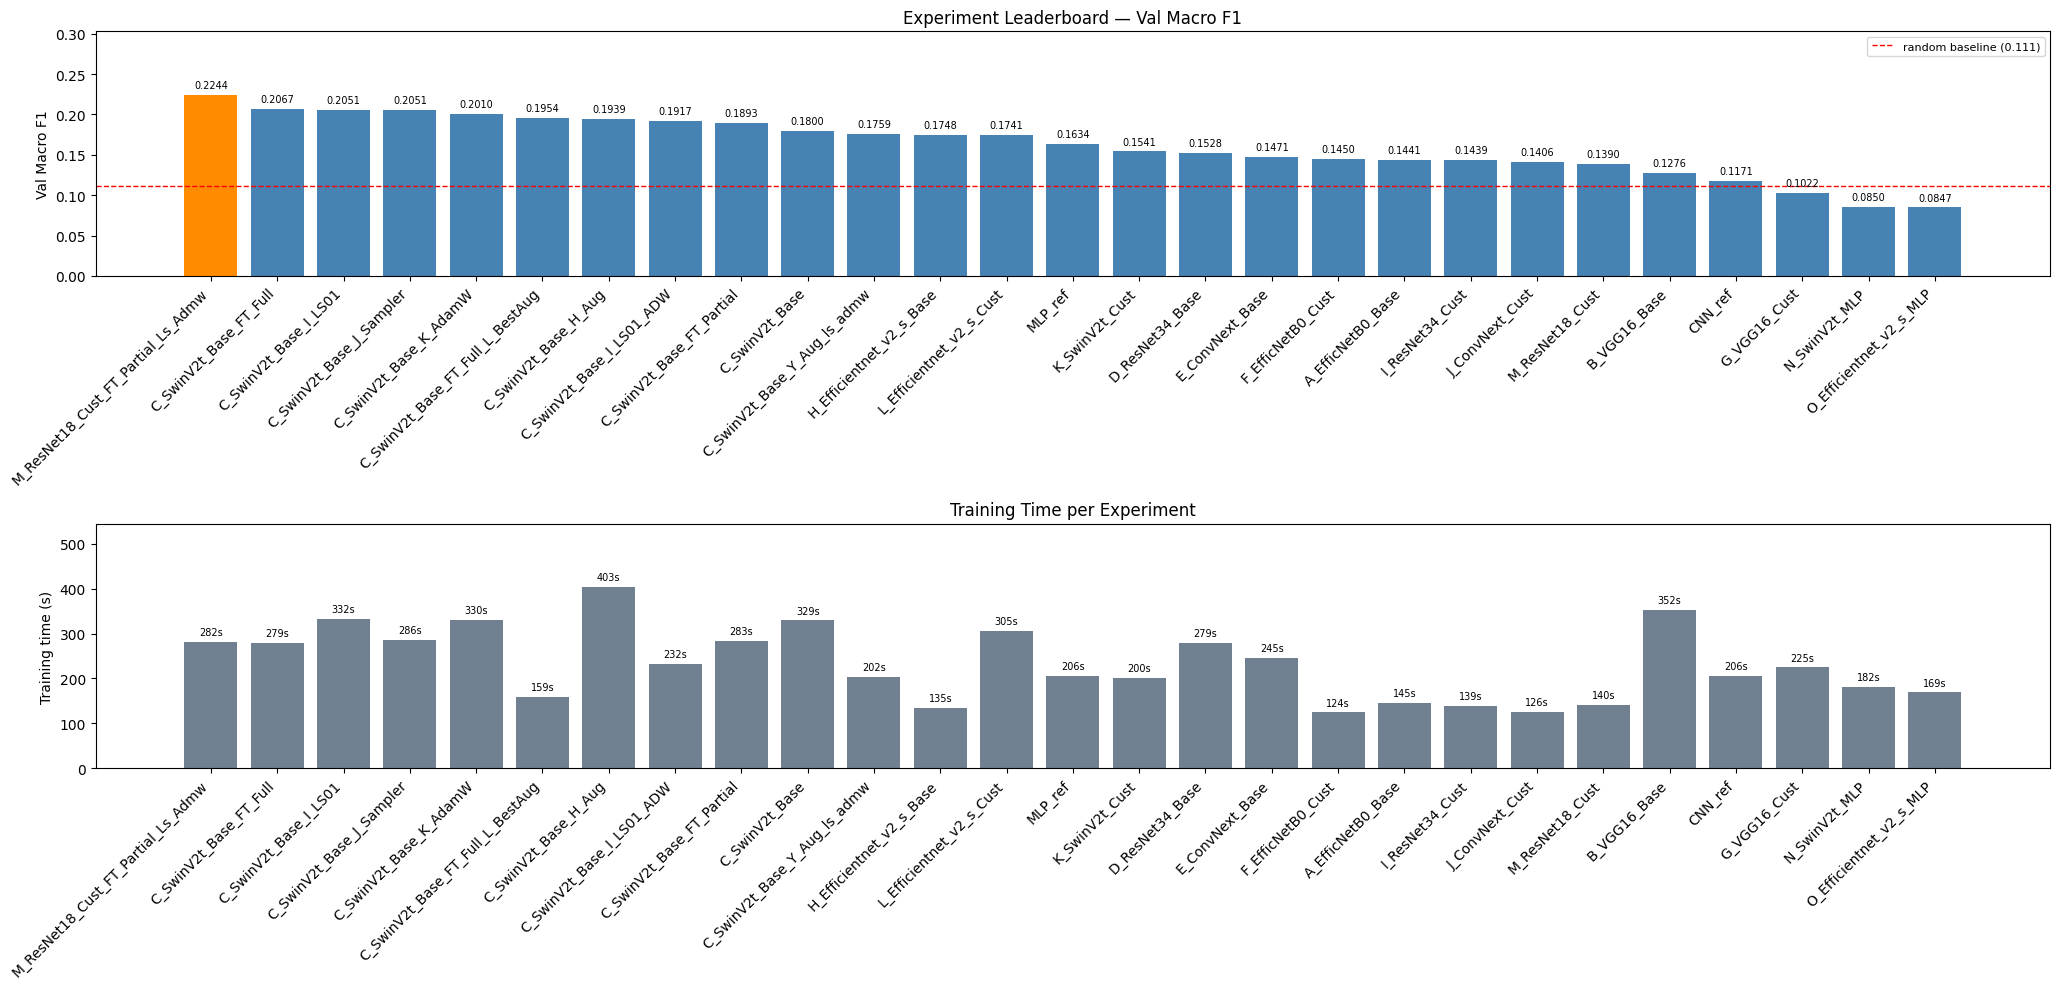


Delta vs frozen baseline (C_SwinV2t_Base, F1=0.1800):
  C_SwinV2t_Base_H_Aug                           +0.0139
  C_SwinV2t_Base_I_LS01                          +0.0251
  C_SwinV2t_Base_J_Sampler                       +0.0251
  C_SwinV2t_Base_K_AdamW                         +0.0210
  C_SwinV2t_Base_I_LS01_ADW                      +0.0117
  C_SwinV2t_Base_Y_Aug_ls_admw                   -0.0041
  C_SwinV2t_Base_Y_Aug_ls_admw                   -0.0041
  C_SwinV2t_Base_FT_Full_L_BestAug               +0.0154

Overall best: M_ResNet18_Cust_FT_Partial_Ls_Admw  (val_F1=0.2244)
-> Best model carried into Part 4 for deep dive + final submission.


In [55]:

# Full leaderboard: Parts 1 + 2 + 3 sorted by val_macro_F1.
print("=== Parts 1 + 2 + 3 -- All Experiments ===")
_print_leaderboard(results_tracker)

# bar chart: all experiments including baselines, frozen, fine-tuned, aug/reg
fig = plot_leaderboard(
    results_tracker,
    out_path=TASK_OUT_DIR / "plots" / f"{TASK_NAME}_leaderboard_part3.png",
)
plt.show()
plt.close(fig)

# per-experiment delta vs the Stage-1 frozen baseline
print(f"\nDelta vs frozen baseline ({best_frozen}, F1={results_tracker[best_frozen]['val_macro_f1']:.4f}):")
base_f1 = results_tracker[best_frozen]["val_macro_f1"]
for stem in PART3_STEMS:
    if stem in results_tracker:
        d = results_tracker[stem]["val_macro_f1"] - base_f1
        sign = "+" if d >= 0 else ""
        print(f"  {stem:<45}  {sign}{d:.4f}")

# pick overall best for Part 4 analysis
best_overall = max(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"])
print(f"\nOverall best: {best_overall}  (val_F1={results_tracker[best_overall]['val_macro_f1']:.4f})")
print("-> Best model carried into Part 4 for deep dive + final submission.")


---

# **Part 4 — Ensemble, Evaluation & Submission**

Full evaluation of all models trained across Parts 0–3. Structure:

| Section | What |
|---------|------|
| 4.1 Per-Class F1 Heatmap | Rows = all models, cols = classes. Which backbone struggles with which type? |
| 4.2 Cross-Task Comparison | MLP baseline vs CNN baseline vs best transfer model — same dataset, fair comparison |
| 4.3 Ensemble | Soft-vote ensemble of the top models. Does combining models beat the best single model? |
| 4.4 Best Model Deep Dive | Training curves + confusion matrix + full classification report for the overall best |
| 4.5 Final Submission | Run the best model on the test set and generate the submission CSV |
| 4.6 Save Outputs | Persist all artefacts (checkpoints, results JSON, plots) to Drive or local disk |

**[FAST_RUN] All plots and scores below are smoke-test only (6 samples/class, 2 epochs). Update after Colab run.**


### 4.1 -- Per-Class F1 Heatmap

Rows = every model trained across Parts 0-3 (MLP_ref, CNN_ref, frozen backbones A-E, partially/fully fine-tuned F-G, augmentation/regularisation variants H-L).  
Columns = the 9 Pokémon type classes.  
Cell colour = per-class macro-F1 score (0 = worst, 1 = best).

**What to look for:**
- Dark columns → hard classes for all models (e.g. Rock vs Ground confusion).
- Rows that brighten more than neighbours → which backbone / regularisation trick helps a specific class.
- MLP_ref / CNN_ref are evaluated with the **64 px loader** (via `loader_fn_registry`); all transfer models use the **224 px loader** — apples-to-apples within each group.

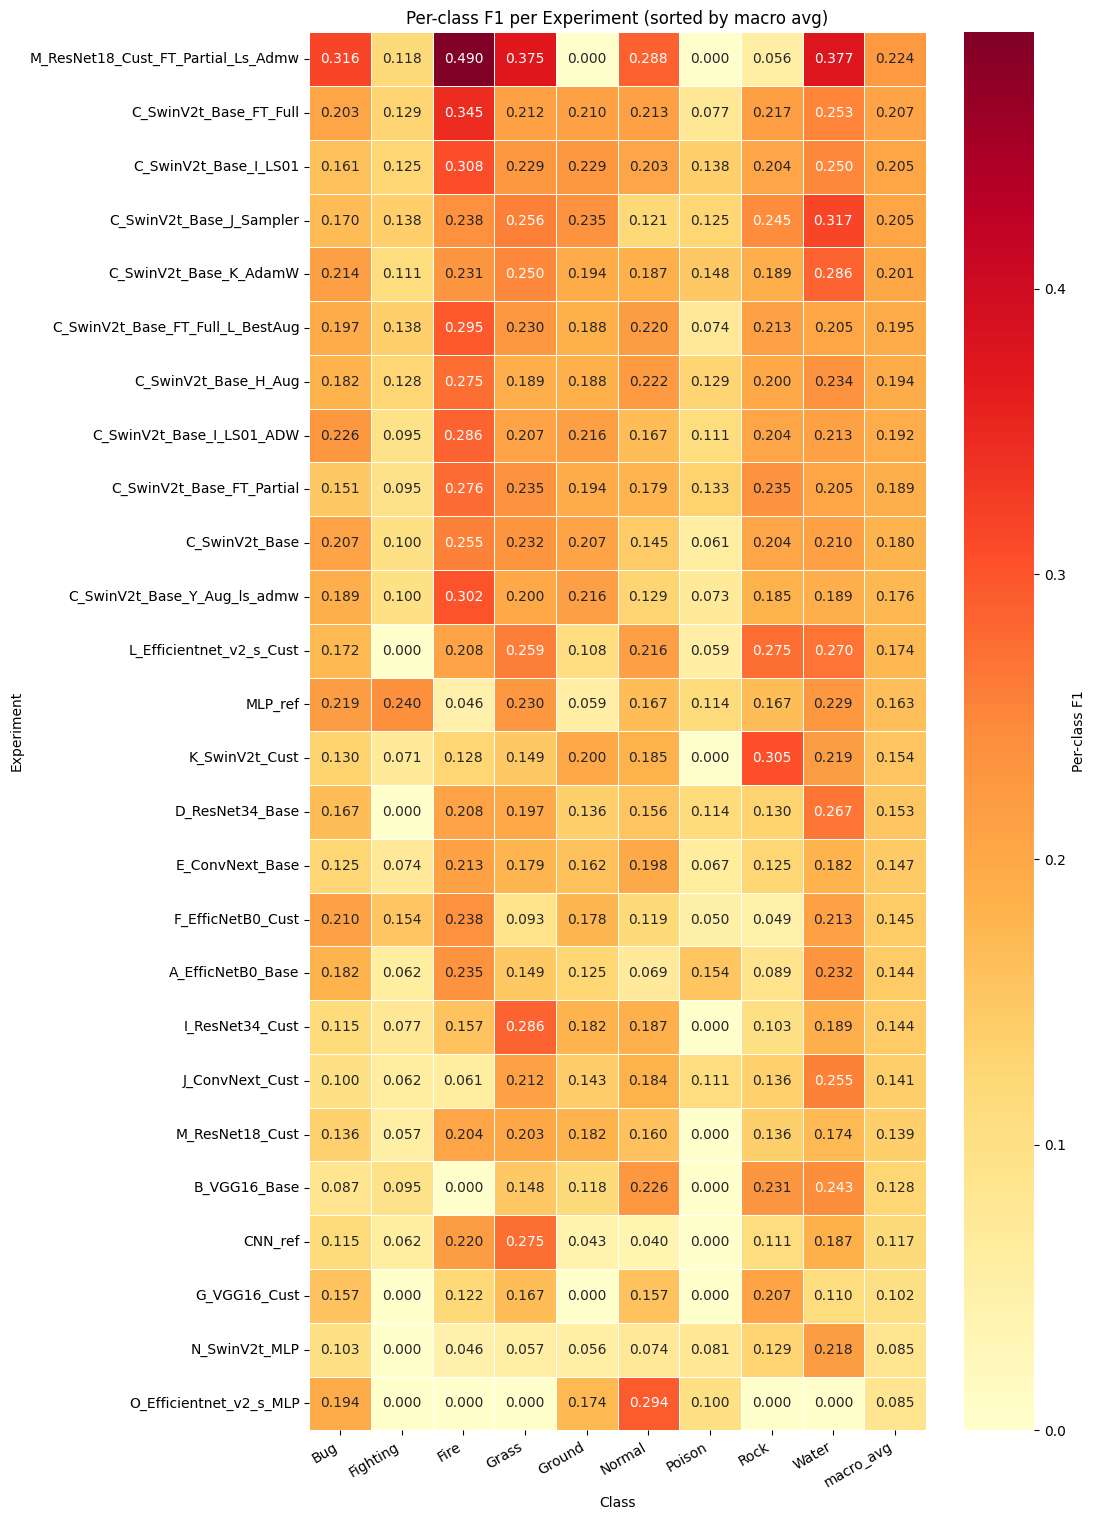

In [56]:

import matplotlib.pyplot as plt
from src.evaluation.analysis import plot_per_class_f1_heatmap

# per-class F1 heatmap: rows = models, cols = classes
# reveals which classes each backbone struggles with (e.g. Ground vs Rock confusion)
# MLP_ref and CNN_ref use 64px loaders via loader_fn_registry;
# all transfer models fall back to the default build_loaders (224px).
fig = plot_per_class_f1_heatmap(
    checkpoint_dir  = TASK_OUT_DIR / "checkpoints",
    model_registry  = {k: v["model"] for k, v in model_registry.items()},
    loader_fn       = build_loaders,
    device          = device,
    out_path        = TASK_OUT_DIR / "plots" / f"{TASK_NAME}_per_class_f1_heatmap.png",
    highlight_best  = True,
    loader_fn_registry = {
        "MLP_ref": build_loaders_64,
        "CNN_ref": build_loaders_64,
    },
)
if fig:
    plt.show()
    plt.close(fig)


### 4.2 -- Cross-Task Comparison

Progression across three levels of modelling complexity, all on the **same Pokémon-type dataset**:

| Baseline | Architecture | Image size |
|----------|-------------|-----------|
| task1 (MLP) | 3-layer MLP | 64 px (flat pixels) |
| task2 (CNN) | Custom MultiScaleCNN | 64 px |
| task3 (MLP_ref / CNN_ref) | Re-run of task1/2 best models | 64 px, same splits |
| task3 (Transfer) | Pretrained backbone + fine-tuning | 224 px, ImageNet init |

The `task3 (MLP_ref)` and `task3 (CNN_ref)` entries are the most rigorous baseline: same data splits, same FAST_RUN flag, same evaluation code as all transfer experiments — any gap vs transfer is purely architectural.

**Numbers will be replaced after the full Colab run.**

In [57]:

import json
from pathlib import Path
import pandas as pd

def _load_best(json_path, task_label):
    """Load results JSON and return a dict with the best experiment's metrics."""
    with open(json_path) as f:
        data = json.load(f)
    exps = data.get("experiments", data)   # handle both {experiments: {...}} and flat
    best_stem = max(exps, key=lambda k: exps[k]["val_macro_f1"])
    return {
        "task"        : task_label,
        "model"       : best_stem,
        "val_F1"      : round(exps[best_stem]["val_macro_f1"], 4),
        "val_acc"     : round(exps[best_stem].get("val_acc", float("nan")), 4),
        "epochs"      : exps[best_stem].get("total_epochs", "?"),
        "train_time_s": round(exps[best_stem].get("train_time_s", 0), 1),
    }

root_path = Path(ROOT)
TASK1_JSON = root_path / "task1" / "outputs" / "results" / "task1_results.json"
TASK2_JSON = root_path / "task2" / "outputs" / "results" / "task2_results.json"
TASK3_JSON = RESULTS_PATH

rows = []
for path, label in [(TASK1_JSON, "task1 (MLP)"), (TASK2_JSON, "task2 (CNN)"), (TASK3_JSON, "task3 (Transfer)")]:
    if path.exists():
        rows.append(_load_best(path, label))
    else:
        print(f"[skip] {path} not found")

# also pull MLP_ref and CNN_ref from task3's own results_tracker for a direct on-same-data comparison
for stem, label in [("MLP_ref", "task3 (MLP_ref)"), ("CNN_ref", "task3 (CNN_ref)")]:
    if stem in results_tracker:
        e = results_tracker[stem]
        rows.append({
            "task"        : label,
            "model"       : stem,
            "val_F1"      : e["val_macro_f1"],
            "val_acc"     : e["val_acc"],
            "epochs"      : e["total_epochs"],
            "train_time_s": e["train_time_s"],
        })

df_cross = pd.DataFrame(rows).set_index("task")
print("=== Cross-Task Comparison (best model per task) ===")
print(df_cross.to_string())

# delta vs task3 MLP_ref (same dataset as all task3 transfer models)
if "task3 (MLP_ref)" in df_cross.index:
    base_f1 = df_cross.loc["task3 (MLP_ref)", "val_F1"]
    print(f"\nDelta vs task3 MLP_ref baseline (same dataset, F1={base_f1:.4f}):")
    for task, row in df_cross.iterrows():
        if task != "task3 (MLP_ref)":
            d = row["val_F1"] - base_f1
            print(f"  {task:<26}  {d:+.4f}")
elif "task1 (MLP)" in df_cross.index:
    base_f1 = df_cross.loc["task1 (MLP)", "val_F1"]
    print(f"\nDelta vs task1 MLP baseline (F1={base_f1:.4f}):")
    for task, row in df_cross.iterrows():
        if task != "task1 (MLP)":
            d = row["val_F1"] - base_f1
            print(f"  {task:<26}  {d:+.4f}")

print("\n[FAST_RUN] All scores are smoke-test results only (6 samples/class, 2 epochs).")
print("Numbers will be replaced after the full Colab runs for each task.")


[skip] /content/DL_Proj/assignment_1/task1/outputs/results/task1_results.json not found
[skip] /content/DL_Proj/assignment_1/task2/outputs/results/task2_results.json not found
=== Cross-Task Comparison (best model per task) ===
                                               model  val_F1  val_acc  epochs  train_time_s
task                                                                                       
task3 (Transfer)  M_ResNet18_Cust_FT_Partial_Ls_Admw  0.2244   0.2929      20         281.9
task3 (MLP_ref)                              MLP_ref  0.1634   0.1757      20         206.4
task3 (CNN_ref)                              CNN_ref  0.1171   0.1464      20         206.2

Delta vs task3 MLP_ref baseline (same dataset, F1=0.1634):
  task3 (Transfer)            +0.0610
  task3 (CNN_ref)             -0.0463

[FAST_RUN] All scores are smoke-test results only (6 samples/class, 2 epochs).
Numbers will be replaced after the full Colab runs for each task.


### 4.3 -- Ensemble Evaluation

Soft-vote ensemble of the **top-2 models** from `results_tracker` (auto-selected by val macro-F1).  
Predictions are the weighted average of per-model softmax probabilities — no re-training needed.

**[FAST_RUN] Scores are smoke-test only (6 samples/class, 2 epochs). Update after Colab run.**

> To try a custom combination, edit `ENSEMBLE_CANDIDATES` below (format: `[(stem, weight), ...]`).

In [58]:
import torch.nn.functional as F
from sklearn.metrics import f1_score as sk_f1
from src.evaluation.persistence import save_experiment_result

# ── per-stem val loader: MLP_ref/CNN_ref need 64 px, transfer models need 224 px ──
_val_64 = build_loaders_64()[1]
def _val_loader_for_stem(stem): return _val_64 if stem in ("MLP_ref", "CNN_ref") else val_loader

def _resolve_model_constructor(stem):
    if stem in model_registry: return model_registry[stem]["model"]
    candidates = {k: v for k, v in model_registry.items() if stem.startswith(k)}
    if candidates: return candidates[max(candidates, key=len)]["model"]
    return None

ENSEMBLE_NAME = "Ensemble_ResNet_Models"
ENSEMBLE_CANDIDATES = [
    ("I_ResNet34_Cust", 1.0),
    ("M_ResNet18_Cust_FT_Partial_Ls_Admw",  1.0),
]

print("Ensemble candidates:")
ens_probs, ens_labels, child_models = None, None, []

for stem, weight in ENSEMBLE_CANDIDATES:
    ckpt = TASK_OUT_DIR / "checkpoints" / f"{stem}.pth"
    constructor = _resolve_model_constructor(stem)
    if not ckpt.exists() or constructor is None: continue

    child_models.append(stem)
    mdl = constructor().to(device)
    mdl.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
    mdl.eval()

    loader = _val_loader_for_stem(stem)
    probs_list, labels_list = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = mdl(imgs.to(device))
            probs_list.append(F.softmax(logits, dim=1).cpu())
            labels_list.extend(lbls.tolist())

    p_tensor = torch.cat(probs_list, dim=0)
    ens_probs = (weight * p_tensor) if ens_probs is None else (ens_probs + weight * p_tensor)
    ens_labels = labels_list

if ens_probs is not None:
    ens_preds = ens_probs.argmax(dim=1).tolist()
    ens_f1 = sk_f1(ens_labels, ens_preds, average="macro", zero_division=0)

    # Register ensemble in tracker
    results_tracker[ENSEMBLE_NAME] = {
        "val_macro_f1": round(ens_f1, 4),
        "val_acc": round(sum([1 for a, b in zip(ens_preds, ens_labels) if a == b]) / len(ens_labels), 4),
        "total_epochs": 0, "train_time_s": 0.0, "history": None, "child_models": child_models
    }
    save_experiment_result(ENSEMBLE_NAME, results_tracker[ENSEMBLE_NAME], RESULTS_PATH)
    print(f"\nEnsemble {ENSEMBLE_NAME} val_macro_F1 : {ens_f1:.4f}")
    _print_leaderboard(results_tracker)
else:
    print("No valid ensemble members found.")

Ensemble candidates:

Ensemble Ensemble_ResNet_Models val_macro_F1 : 0.2074


,name,val_F1,val_acc,epochs,time(s)
rank,,,,,
1,M_ResNet18_Cust_FT_Partial_Ls_Admw,0.2244,0.2929,20,281.9
2,Ensemble_ResNet_Models,0.2074,0.2720,0,0.0
3,C_SwinV2t_Base_FT_Full,0.2067,0.2218,14,278.9
4,C_SwinV2t_Base_I_LS01,0.2051,0.2134,20,332.1
5,C_SwinV2t_Base_J_Sampler,0.2051,0.2218,17,286.0
6,C_SwinV2t_Base_K_AdamW,0.2010,0.2134,20,330.5
7,C_SwinV2t_Base_FT_Full_L_BestAug,0.1954,0.2092,8,159.4
8,C_SwinV2t_Base_H_Aug,0.1939,0.2008,20,403.0
9,C_SwinV2t_Base_I_LS01_ADW,0.1917,0.1967,14,231.6


### 4.4 -- Best Model Deep Dive

Full diagnostic on the **overall best** model by val macro-F1 (auto-selected from `results_tracker`):

1. **Training curves** — loss & accuracy over epochs (train vs val). Did the model overfit? Did early stopping trigger?
2. **Classification report** — per-class precision / recall / F1 on the full validation set.
3. **Confusion matrix** — which classes does the model confuse most? (e.g. Rock ↔ Ground)

All three artefacts are saved to `outputs/plots/`.

Best model: M_ResNet18_Cust_FT_Partial_Ls_Admw  (val_F1=0.2244)

--- Classification Report (val set) ---


,precision,recall,f1-score,support
Bug,0.330000,0.300000,0.320000,30.000000
Fighting,0.200000,0.080000,0.120000,12.000000
Fire,0.460000,0.520000,0.490000,23.000000
Grass,0.380000,0.380000,0.380000,32.000000
Ground,0.000000,0.000000,0.000000,14.000000
Normal,0.250000,0.340000,0.290000,44.000000
Poison,0.000000,0.000000,0.000000,13.000000
Rock,0.060000,0.050000,0.060000,20.000000
Water,0.360000,0.390000,0.380000,51.000000
accuracy,,,0.290000,239.000000


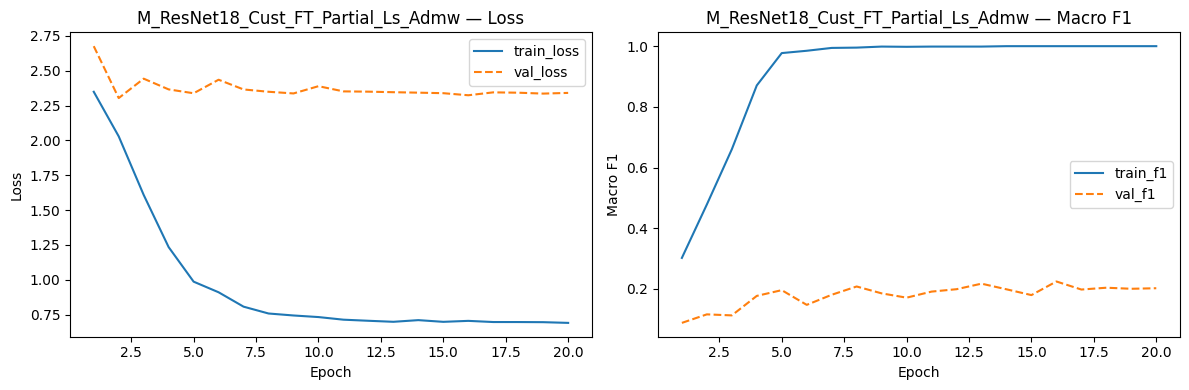

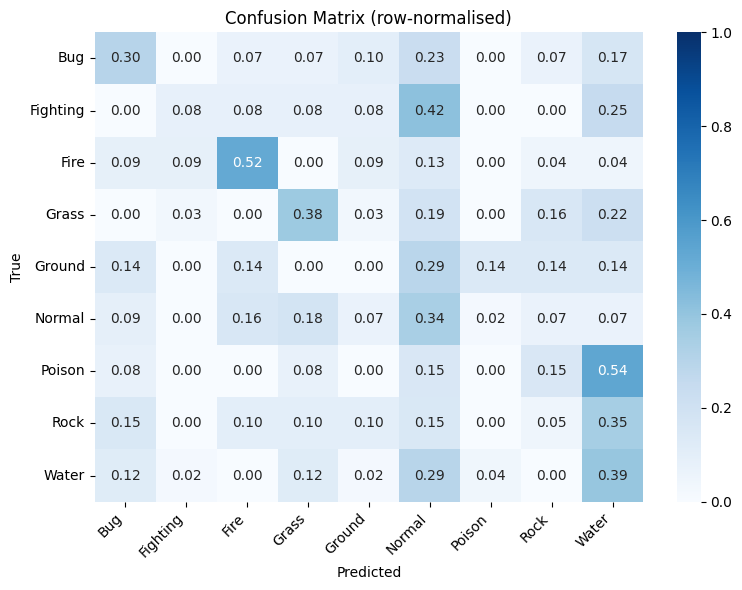

In [59]:
from src.evaluation.analysis import print_classification_report

# overall best (solo only -- no ensembles in task 3)
best_overall = max(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"])
print(f"Best model: {best_overall}  (val_F1={results_tracker[best_overall]['val_macro_f1']:.4f})")

# resolve model constructor: prefer exact registry match, then fall back to prefix matching
# (e.g. "D_ResNet34_Base_FT_Partial_L_BestAug" shares architecture with "D_ResNet34_Base")
if best_overall in model_registry:
    _best_constructor = model_registry[best_overall]["model"]
else:
    # find the longest registry key that is a prefix of the best stem
    candidates = {k: v for k, v in model_registry.items() if best_overall.startswith(k)}
    if candidates:
        parent_key = max(candidates, key=len)
        _best_constructor = candidates[parent_key]["model"]
        print(f"  [info] '{best_overall}' not in registry; using architecture from '{parent_key}'")
    else:
        raise KeyError(
            f"Cannot find architecture for '{best_overall}' in model_registry. "
            f"Re-run the experiment cells first to register derived stems, or add it manually."
        )

best_model = _best_constructor().to(device)
best_ckpt  = TASK_OUT_DIR / "checkpoints" / f"{best_overall}.pth"
best_model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))

# pick correct val loader: MLP_ref/CNN_ref need 64 px; transfer models need 224 px
_best_val_loader = _val_loader_for_stem(best_overall)

# classification report: precision/recall/F1 per class on val set
print("\n--- Classification Report (val set) ---")
all_labels_list, all_preds = print_classification_report(
    best_model, _best_val_loader, device, CLASSES
)

# training curves
best_history = results_tracker[best_overall]["history"]
if best_history:
    fig = plot_history(
        best_history,
        TASK_OUT_DIR / "plots" / f"{TASK_NAME}_history_{best_overall}.png",
        title=best_overall,
    )
    plt.show()
    plt.close(fig)

# confusion matrix
fig = plot_confusion_matrix(
    all_labels_list, all_preds, CLASSES,
    TASK_OUT_DIR / "plots" / f"{TASK_NAME}_confusion_{best_overall}.png",
)
plt.show()
plt.close(fig)


### 4.5 -- Final Submission

Run the overall best model on the **held-out test set** and write the Kaggle submission CSV.

- The correct test loader is selected automatically (`64 px` for MLP_ref/CNN_ref, `224 px` for transfer models) via `_make_test_loader`.
- `run_experiment` cells already auto-generate a submission when a new best is found — this cell is a **final confirmation / explicit re-run** in case the checkpoint was updated after the last auto-save.

In [60]:
best_overall = max(results_tracker, key=lambda k: results_tracker[k]["val_macro_f1"])
print(f"Generating submission for: {best_overall} (val_F1={results_tracker[best_overall]['val_macro_f1']:.4f})")

if "child_models" in results_tracker[best_overall]:
    combined_probs = None
    for stem in results_tracker[best_overall]["child_models"]:
        mdl = _resolve_model_constructor(stem)().to(device)
        mdl.load_state_dict(torch.load(TASK_OUT_DIR / "checkpoints" / f"{stem}.pth", map_location=device, weights_only=True))
        mdl.eval()
        probs = []
        tl = _make_test_loader(stem)
        with torch.no_grad():
            for imgs, _ in tl: probs.append(F.softmax(mdl(imgs.to(device)), dim=1).cpu())
        p_tensor = torch.cat(probs, dim=0)
        combined_probs = p_tensor if combined_probs is None else (combined_probs + p_tensor)
    test_preds = combined_probs.argmax(dim=1).tolist()
    final_tl = _make_test_loader(results_tracker[best_overall]["child_models"][0])
else:
    mdl = _resolve_model_constructor(best_overall)().to(device)
    mdl.load_state_dict(torch.load(TASK_OUT_DIR / "checkpoints" / f"{best_overall}.pth", map_location=device, weights_only=True))
    mdl.eval()
    final_tl = _make_test_loader(best_overall)
    test_preds = []
    with torch.no_grad():
        for imgs, _ in final_tl: test_preds.extend(mdl(imgs.to(device)).argmax(dim=1).cpu().tolist())

generate_submission_from_preds(final_tl, test_preds, CLASSES, SUB_PATH)
validate_submission(SUB_PATH)
print(f"Submission saved -> {SUB_PATH}")

Generating submission for: M_ResNet18_Cust_FT_Partial_Ls_Admw (val_F1=0.2244)
Submission saved: task3/outputs/results/submission_task3.csv  (300 rows)
Submission valid: 300 rows, all class names correct.
Submission saved -> task3/outputs/results/submission_task3.csv


## 4.6 -- Save Outputs

Persists all artefacts from this run to Drive (Colab) or prints the local output paths.

- **Colab + Drive:** zips `task3/outputs/` and writes to `DRIVE_OUTPUTS_DIR` in your MyDrive.
- **Colab without Drive:** zips and triggers a browser download via `google.colab.files`.
- **Local:** prints paths to checkpoints, results JSON, and submission CSV (already on disk).

In [61]:
# Save final outputs to Drive (Colab) or create a local zip for download.
if USE_DRIVE:
    save_outputs(TASK_OUT_DIR, TASK_NAME, in_colab=IN_COLAB, use_drive=USE_DRIVE, drive_dir=DRIVE_OUTPUTS_DIR)
elif IN_COLAB:
    # running on Colab without Drive -- zip + download directly
    import shutil
    from google.colab import files
    zip_path = str(TASK_OUT_DIR) + ".zip"
    shutil.make_archive(str(TASK_OUT_DIR), "zip", TASK_OUT_DIR)
    files.download(zip_path)
    print(f"Downloading {zip_path}")
else:
    # local run -- outputs are already in TASK_OUT_DIR
    print(f"[save_outputs] Local run -- outputs at: {TASK_OUT_DIR}")
    print(f"  Checkpoints : {list((TASK_OUT_DIR / 'checkpoints').glob('*.pth'))}")
    print(f"  Results JSON: {RESULTS_PATH}  (exists: {RESULTS_PATH.exists()})")
    print(f"  Submission  : {SUB_PATH}  (exists: {SUB_PATH.exists()})")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>